In [1]:
import numpy as np
import math
import cvxpy as cp
import itertools
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

sin = math.sin
cos = math.cos
tan = math.tan
th_max = np.pi/2
ph_max = np.pi/2
Ds=0.5

# coefficients for pairwise ECBF constraint
lam_pair = 8  # tune
alpha3 = 4.0 * lam_pair
alpha2 = 6.0 * lam_pair**2
alpha1 = 4.0 * lam_pair**3
alpha0 = lam_pair**4


def PelicanModelDirect(time, dt, state, control_inputs, system_parameters, sim_parameters):
    """
    One-step quad dynamics driven directly by control inputs:
    control_inputs = [up, uq, ur, u_thrust]
    state = [ph, th, ps, p, q, r, x, y, z, vx, vy, vz]
    """
    m = system_parameters["m"]
    g = system_parameters["g"]
    Ix = system_parameters["Ix"]
    Iy = system_parameters["Iy"]
    Iz = system_parameters["Iz"]
    kr = system_parameters.get("kr", 0.01)
    kt = system_parameters.get("kt", 0.01)

    dist_x = 0.1 * np.sin(time) if sim_parameters.get("disturbanceX", 0) else 0.0
    dist_y = 0.1 * np.sin(time) if sim_parameters.get("disturbanceY", 0) else 0.0
    dist_z = 0.1 * np.sin(time) if sim_parameters.get("disturbanceZ", 0) else 0.0

    up, uq, ur, u_thrust = control_inputs
    ph, th, ps, p, q, r, x, y, z, vx, vy, vz = state

    # attitude kinematics
    ph += dt * (p + (r * np.cos(ph) * np.sin(th)) / np.cos(th) + (q * np.sin(ph) * np.sin(th)) / np.cos(th))
    th += dt * (q * np.cos(ph) - r * np.sin(ph))
    ps += dt * ((r * np.cos(ph)) / np.cos(th) + (q * np.sin(ph)) / np.cos(th))

    # angular dynamics
    p += dt * (up - kr * p + (Iy - Iz) * q * r) / Ix
    q += dt * (uq - kr * q + (Iz - Ix) * p * r) / Iy
    r += dt * (ur - kr * r + (Ix - Iy) * p * q) / Iz

    # position
    x += dt * vx
    y += dt * vy
    z += dt * vz

    # translational dynamics
    vx += dt * (
        dist_x / m
        - (kt * vx) / m
        + (u_thrust * (np.sin(ph) * np.sin(ps) + np.cos(ph) * np.cos(ps) * np.sin(th))) / m
    )
    vy += -dt * (
        (kt * vy) / m
        - dist_y / m
        + (u_thrust * (np.cos(ps) * np.sin(ph) - np.cos(ph) * np.sin(ps) * np.sin(th))) / m
    )
    vz += -dt * (
        g
        - dist_z / m
        + (kt * vz) / m
        - (u_thrust * np.cos(ph) * np.cos(th)) / m
    )

    return np.array([ph, th, ps, p, q, r, x, y, z, vx, vy, vz], dtype=float)


# ----------------------------
# Per-quad configuration
# ----------------------------

class QuadConfig:
    def __init__(self, name, des_radius, des_x, des_y, des_height, des_yaw, des_speed,
                 gains, th_max, ph_max, cbf_lambdas, qp_weights):
        self.name = name

        # desired trajectory parameters (your circle)
        self.des_radius = float(des_radius)
        self.des_x = float(des_x)
        self.des_y = float(des_y)
        self.des_height = float(des_height)
        self.des_yaw = float(des_yaw)
        self.des_speed = float(des_speed)

        # gains dict: k1..k14 (or anything you need)
        self.gains = dict(gains)

        # angle constraints
        self.th_max = float(th_max)
        self.ph_max = float(ph_max)

        # cbf lambdas (for your single-quad roll/pitch cbfs)
        self.cbf_lambdas = dict(cbf_lambdas)  # expects {'lam_th':..., 'lam_ph':...}

        # QP weights
        self.qp_weights = dict(qp_weights)    # expects {'Q_u':..., 'P_delta':...}


# ----------------------------
# Environment (shared)
# ----------------------------

class Environment:
    def __init__(self, system_params, sim_params, M_map):
        self.system = dict(system_params)
        self.sim = dict(sim_params)
        self.M_map = np.array(M_map, dtype=float)

    def disturbances(self, t):
        # You can expand this to spatially varying or agent-dependent disturbances
        return np.array([0.0, 0.0, 0.0], dtype=float)


# ----------------------------
# Controller wrapper
# ----------------------------

def compute_tracking_terms(agent_id, state, zeta1, zeta2, cfg: QuadConfig, env: Environment, t, world_snapshot):
    """
    YOU IMPLEMENT THIS ONCE by moving your long Lie-derivative block here.

    Must return a dictionary with:
      - D: (4,4) numpy array
      - rhs: (4,) numpy array
      - cbf_terms: dict with the needed scalars to build your constraints:
            th: Lf2h_th, Lg3Lfh_th, Lg4Lfh_th, Lfh_th, h_th
            ph: Lf2h_ph, Lg2Lfh_ph, Lg3Lfh_ph, Lg4Lfh_ph, Lfh_ph, h_ph

    Also anything else you want to log.
    """
    # ---- unpack ----
    ph, th, ps, p, q, r, x, y, z, vx, vy, vz = state
    m = env.system["m"]
    kt = env.system.get("kt", 0.01)
    kr = env.system.get("kr", 0.01)
    Ix = env.system["Ix"]
    Iy = env.system["Iy"]
    Iz = env.system["Iz"]
    gains = cfg.gains
    g = env.system["g"]  
    

    # desired parameters
    des_radius = cfg.des_radius
    des_x = cfg.des_x
    des_y = cfg.des_y
    des_height = cfg.des_height
    des_yaw = cfg.des_yaw
    des_speed = cfg.des_speed

    # gains
    k1, k2, k3, k4 = gains["k1"], gains["k2"], gains["k3"], gains["k4"]
    k5, k6, k7, k8 = gains["k5"], gains["k6"], gains["k7"], gains["k8"]
    k9, k10, k11, k12 = gains["k9"], gains["k10"], gains["k11"], gains["k12"]
    k13, k14 = gains["k13"], gains["k14"]

    # NOTE:
    # Disturbances in your long expressions were dist_x/dist_y/dist_z.
    # Use env.disturbances(t) or keep them zero.
    dist_x, dist_y, dist_z = env.disturbances(t)

    # Transformed states
    xi1_1 = -des_radius**2 + (-des_x + x)**2 + (-des_y + y)**2
    xi1_2 = vx*(-2*des_x + 2*x) + vy*(-2*des_y + 2*y)
    xi1_3 = 2*vx**2 + 2*vy**2 + (-2*des_x + 2*x)*(dist_x - kt*vx + zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(dist_y - kt*vy - zeta1*sin(ph)*cos(ps) + zeta1*sin(ps)*sin(th)*cos(ph))/m
    xi1_4 = zeta2*((-2*des_x + 2*x)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph))/m) + (q*cos(ph) - r*sin(ph))*(zeta1*(-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + zeta1*(-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m) + (-kt*(-2*des_x + 2*x)/m + 4*vx)*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m) + (-kt*(-2*des_y + 2*y)/m + 4*vy)*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m) + ((-2*des_x + 2*x)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m)*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th)) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th)) + 2*vx*(dist_x - kt*vx + zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m + 2*vy*(dist_y - kt*vy - zeta1*sin(ph)*cos(ps) + zeta1*sin(ps)*sin(th)*cos(ph))/m

    Lg1Lf3S1 = (-2*des_x + 2*x)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph))/m

    Lg2Lf3S1 = ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)/Ix

    Lg3Lf3S1 = (((-2*des_x + 2*x)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m)*sin(ph)/cos(th) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*sin(ph)*sin(th)/cos(th) + (zeta1*(-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + zeta1*(-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m)*cos(ph))/Iy
    
    Lg4Lf3S1 = 0
    
    Lf4S1 = vx*(-2*kt*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/m + 2*zeta1*(q*cos(ph) - r*sin(ph))*cos(ph)*cos(ps)*cos(th)/m + 2*zeta2*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m + 2*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + 2*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/m) + vy*(-2*kt*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/m + 2*zeta1*(q*cos(ph) - r*sin(ph))*sin(ps)*cos(ph)*cos(th)/m + 2*zeta2*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph))/m + 2*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m + 2*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/m) + zeta2*((q*cos(ph) - r*sin(ph))*((-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + (-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m) + ((-2*des_x + 2*x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th)) + ((-2*des_x + 2*x)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-sin(ph)*sin(ps)*sin(th) - cos(ph)*cos(ps))/m)*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th)) + 2*vx*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m + 2*vy*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph))/m + (sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))*(-kt*(-2*des_x + 2*x)/m + 4*vx)/m - (sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))*(-kt*(-2*des_y + 2*y)/m + 4*vy)/m) + (q*cos(ph) - r*sin(ph))*(zeta2*((-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + (-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m) + (q*cos(ph) - r*sin(ph))*(-zeta1*(-2*des_x + 2*x)*sin(th)*cos(ph)*cos(ps)/m - zeta1*(-2*des_y + 2*y)*sin(ps)*sin(th)*cos(ph)/m) + ((-2*des_x + 2*x)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m)*(q*sin(ph)*sin(th)/cos(th)**2 + r*sin(th)*cos(ph)/cos(th)**2) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*(q*sin(ph)*sin(th)**2/cos(th)**2 + q*sin(ph) + r*sin(th)**2*cos(ph)/cos(th)**2 + r*cos(ph)) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(-zeta1*(-2*des_x + 2*x)*sin(ps)*cos(ph)*cos(th)/m + zeta1*(-2*des_y + 2*y)*cos(ph)*cos(ps)*cos(th)/m) + (-zeta1*(-2*des_x + 2*x)*sin(ph)*cos(ps)*cos(th)/m - zeta1*(-2*des_y + 2*y)*sin(ph)*sin(ps)*cos(th)/m)*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th)) + 2*vx*zeta1*cos(ph)*cos(ps)*cos(th)/m + 2*vy*zeta1*sin(ps)*cos(ph)*cos(th)/m + zeta1*(-kt*(-2*des_x + 2*x)/m + 4*vx)*cos(ph)*cos(ps)*cos(th)/m + zeta1*(-kt*(-2*des_y + 2*y)/m + 4*vy)*sin(ps)*cos(ph)*cos(th)/m) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta2*((-2*des_x + 2*x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m) + (q*cos(ph) - r*sin(ph))*(-zeta1*(-2*des_x + 2*x)*sin(ps)*cos(ph)*cos(th)/m + zeta1*(-2*des_y + 2*y)*cos(ph)*cos(ps)*cos(th)/m) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(ps) - zeta1*sin(th)*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m)*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th)) + ((-2*des_x + 2*x)*(zeta1*sin(ph)*sin(ps)*sin(th) + zeta1*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m)*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th)) + 2*vx*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + 2*vy*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m - zeta1*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps))*(-kt*(-2*des_y + 2*y)/m + 4*vy)/m + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))*(-kt*(-2*des_x + 2*x)/m + 4*vx)/m) + (p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))*(zeta2*((-2*des_x + 2*x)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-sin(ph)*sin(ps)*sin(th) - cos(ph)*cos(ps))/m) + (-q*sin(ph) - r*cos(ph))*(zeta1*(-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + zeta1*(-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m) + (q*cos(ph) - r*sin(ph))*(-zeta1*(-2*des_x + 2*x)*sin(ph)*cos(ps)*cos(th)/m - zeta1*(-2*des_y + 2*y)*sin(ph)*sin(ps)*cos(th)/m) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(ps) - zeta1*sin(th)*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m)*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th)) + ((-2*des_x + 2*x)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m)*(q*cos(ph)/cos(th) - r*sin(ph)/cos(th)) + ((-2*des_x + 2*x)*(zeta1*sin(ph)*sin(ps)*sin(th) + zeta1*cos(ph)*cos(ps))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m)*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th)) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*(q*sin(th)*cos(ph)/cos(th) - r*sin(ph)*sin(th)/cos(th)) + 2*vx*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + 2*vy*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m + zeta1*(-kt*(-2*des_x + 2*x)/m + 4*vx)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))/m - zeta1*(-kt*(-2*des_y + 2*y)/m + 4*vy)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps))/m) + (dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)*(4*dist_x/m - 6*kt*vx/m - kt*(-kt*(-2*des_x + 2*x)/m + 4*vx)/m + 4*zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m + 2*(dist_x - kt*vx + zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m) + (dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)*(4*dist_y/m - 6*kt*vy/m - kt*(-kt*(-2*des_y + 2*y)/m + 4*vy)/m - 4*zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m + 2*(dist_y - kt*vy - zeta1*sin(ph)*cos(ps) + zeta1*sin(ps)*sin(th)*cos(ph))/m) + (Ix*p*q - Iy*p*q - kr*r)*(((-2*des_x + 2*x)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m)*cos(ph)/cos(th) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*sin(th)*cos(ph)/cos(th) - (zeta1*(-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + zeta1*(-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m)*sin(ph))/Iz + (-Ix*p*r + Iz*p*r - kr*q)*(((-2*des_x + 2*x)*(zeta1*sin(ph)*cos(ps) - zeta1*sin(ps)*sin(th)*cos(ph))/m + (-2*des_y + 2*y)*(zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/m)*sin(ph)/cos(th) + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*sin(ph)*sin(th)/cos(th) + (zeta1*(-2*des_x + 2*x)*cos(ph)*cos(ps)*cos(th)/m + zeta1*(-2*des_y + 2*y)*sin(ps)*cos(ph)*cos(th)/m)*cos(ph))/Iy + ((-2*des_x + 2*x)*(-zeta1*sin(ph)*sin(th)*cos(ps) + zeta1*sin(ps)*cos(ph))/m + (-2*des_y + 2*y)*(-zeta1*sin(ph)*sin(ps)*sin(th) - zeta1*cos(ph)*cos(ps))/m)*(Iy*q*r - Iz*q*r - kr*p)/Ix
    
    xi2_1 = z - des_height
    xi2_2 = vz
    xi2_3 = (dist_z - g*m - kt*vz + zeta1*cos(ph)*cos(th))/m
    xi2_4 = (-dist_z*kt + g*kt*m + kt**2*vz - kt*zeta1*cos(ph)*cos(th) - m*p*zeta1*sin(ph)*cos(th) - m*q*zeta1*sin(th) + m*zeta2*cos(ph)*cos(th))/m**2
    
    Lg1Lf3S2 = cos(ph)*cos(th)/m
    Lg2Lf3S2 = -(zeta1*cos(th)*sin(ph))/(Ix*m)
    Lg3Lf3S2 = -(zeta1*sin(th))/(Iy*m)
    Lg4Lf3S2 = 0
    Lf4S2 = kt**2*(dist_z/m - g - kt*vz/m + zeta1*cos(ph)*cos(th)/m)/m**2 + zeta2*(-kt*cos(ph)*cos(th) - m*p*sin(ph)*cos(th) - m*q*sin(th))/m**2 + (q*cos(ph) - r*sin(ph))*(kt*zeta1*sin(th)*cos(ph) + m*p*zeta1*sin(ph)*sin(th) - m*q*zeta1*cos(th) - m*zeta2*sin(th)*cos(ph))/m**2 + (p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))*(kt*zeta1*sin(ph)*cos(th) - m*p*zeta1*cos(ph)*cos(th) - m*zeta2*sin(ph)*cos(th))/m**2 - zeta1*(-Ix*p*r + Iz*p*r - kr*q)*sin(th)/(Iy*m) - zeta1*(Iy*q*r - Iz*q*r - kr*p)*sin(ph)*cos(th)/(Ix*m)
    
    eta1_1 = np.arctan2(y-des_y,x-des_x)
    eta1_2 = (vx*(des_y - y) - vy*(des_x - x))/((des_x - x)**2 + (des_y - y)**2)
    eta1_3 = vx*(vy/((des_x - x)**2 + (des_y - y)**2) + (2*des_x - 2*x)*(vx*(des_y - y) - vy*(des_x - x))/((des_x - x)**2 + (des_y - y)**2)**2) + vy*(-vx/((des_x - x)**2 + (des_y - y)**2) + (2*des_y - 2*y)*(vx*(des_y - y) - vy*(des_x - x))/((des_x - x)**2 + (des_y - y)**2)**2) + (-des_x + x)*(dist_y - kt*vy - zeta1*sin(ph)*cos(ps) + zeta1*sin(ps)*sin(th)*cos(ph))/(m*((des_x - x)**2 + (des_y - y)**2)) + (des_y - y)*(dist_x - kt*vx + zeta1*sin(ph)*sin(ps) + zeta1*sin(th)*cos(ph)*cos(ps))/(m*((des_x - x)**2 + (des_y - y)**2))
    eta1_4 = vx*((4*des_x - 4*x)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (m*(vx*(-2*vx*(des_y - y) + vy*(-2*des_x + 2*x) + 4*vy*(des_x - x)) - vy*(vx*(-2*des_x + 2*x) - 2*vy*(des_y - y))) + (-2*des_x + 2*x)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (m*(vx*(-2*vx*(des_x - x) + vy*(-2*des_y + 2*y)) - vy*(vx*(-2*des_y + 2*y) + 4*vx*(des_y - y) - 2*vy*(des_x - x))) + (-2*des_y + 2*y)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + zeta2*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*cos(ph) - r*sin(ph))*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2))
    
    Lg1Lf3P1 = ((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2))
    Lg2Lf3P1 = (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))/(Ix*m*((des_x - x)**2 + (des_y - y)**2))
    Lg3Lf3P1 = ((zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))*sin(ph)/(m*((des_x - x)**2 + (des_y - y)**2)*cos(th)) + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*sin(ph)*sin(th)/(m*((des_x - x)**2 + (des_y - y)**2)*cos(th)) + (-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))*cos(ph)/(m*((des_x - x)**2 + (des_y - y)**2)))/Iy
    Lg4Lf3P1 = 0
    Lf4P1 = vx*(vx*((4*des_x - 4*x)*(6*des_x - 6*x)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**4) + 2*(4*des_x - 4*x)*(m*(vx*(-2*vx*(des_y - y) + vy*(-2*des_x + 2*x) + 4*vy*(des_x - x)) - vy*(vx*(-2*des_x + 2*x) - 2*vy*(des_y - y))) + (-2*des_x + 2*x)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) - 4*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (-4*m*vx*vy + 2*(-2*des_x + 2*x)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + 2*(des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + 2*(des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_x - 4*x)*(m*(vx*(-2*vx*(des_x - x) + vy*(-2*des_y + 2*y)) - vy*(vx*(-2*des_y + 2*y) + 4*vx*(des_y - y) - 2*vy*(des_x - x))) + (-2*des_y + 2*y)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (6*des_x - 6*x)*(4*des_y - 4*y)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**4) + (4*des_y - 4*y)*(m*(vx*(-2*vx*(des_y - y) + vy*(-2*des_x + 2*x) + 4*vy*(des_x - x)) - vy*(vx*(-2*des_x + 2*x) - 2*vy*(des_y - y))) + (-2*des_x + 2*x)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (m*(2*vx**2 - 2*vy**2) + (-2*des_x + 2*x)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))) + (-2*des_y + 2*y)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + zeta1*(q*cos(ph) - r*sin(ph))*sin(ps)*cos(ph)*cos(th)/(m*((des_x - x)**2 + (des_y - y)**2)) - zeta1*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps))*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) - zeta1*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + zeta2*(2*des_x - 2*x)*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + zeta2*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph))/(m*((des_x - x)**2 + (des_y - y)**2)) + (2*des_x - 2*x)*(q*cos(ph) - r*sin(ph))*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (2*des_x - 2*x)*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (2*des_x - 2*x)*(zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (4*des_x - 4*x)*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (4*des_x - 4*x)*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (-kt*(-2*des_x + 2*x)*(des_y - y) + m*(-4*vx*(des_y - y) + 4*vy*(des_x - x)))*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)*(kt*(-2*des_x + 2*x)*(des_x - x) - kt*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*(-2*des_x + 2*x) + vx*(2*des_x - 2*x) + 4*vy*(des_y - y)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*(vx*((4*des_x - 4*x)*(6*des_y - 6*y)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**4) + (4*des_x - 4*x)*(m*(vx*(-2*vx*(des_x - x) + vy*(-2*des_y + 2*y)) - vy*(vx*(-2*des_y + 2*y) + 4*vx*(des_y - y) - 2*vy*(des_x - x))) + (-2*des_y + 2*y)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (4*des_y - 4*y)*(m*(vx*(-2*vx*(des_y - y) + vy*(-2*des_x + 2*x) + 4*vy*(des_x - x)) - vy*(vx*(-2*des_x + 2*x) - 2*vy*(des_y - y))) + (-2*des_x + 2*x)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (m*(2*vx**2 - 2*vy**2) + (-2*des_x + 2*x)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))) + (-2*des_y + 2*y)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(6*des_y - 6*y)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**4) + 2*(4*des_y - 4*y)*(m*(vx*(-2*vx*(des_x - x) + vy*(-2*des_y + 2*y)) - vy*(vx*(-2*des_y + 2*y) + 4*vx*(des_y - y) - 2*vy*(des_x - x))) + (-2*des_y + 2*y)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) - 4*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (4*m*vx*vy + 2*(des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + 2*(-2*des_y + 2*y)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))) + 2*(des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) - zeta1*(q*cos(ph) - r*sin(ph))*cos(ph)*cos(ps)*cos(th)/(m*((des_x - x)**2 + (des_y - y)**2)) - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) - zeta1*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + zeta2*(2*des_y - 2*y)*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + zeta2*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps))/(m*((des_x - x)**2 + (des_y - y)**2)) + (2*des_y - 2*y)*(q*cos(ph) - r*sin(ph))*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (2*des_y - 2*y)*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (2*des_y - 2*y)*(zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (4*des_y - 4*y)*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (4*des_y - 4*y)*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (kt*(des_x - x)*(-2*des_y + 2*y) + m*(-4*vx*(des_y - y) - 2*vy*(-des_x + x) + 2*vy*(des_x - x)))*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)*(-kt*(-2*des_y + 2*y)*(des_y - y) + kt*((des_x - x)**2 + (des_y - y)**2) + m*(-4*vx*(des_x - x) + vy*(-2*des_y + 2*y) - vy*(2*des_y - 2*y)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + zeta2*(vx*((4*des_x - 4*x)*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + ((-2*des_x + 2*x)*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))) + (-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + ((-2*des_y + 2*y)*((des_x - x)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)) + (des_y - y)*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))) + (-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + (q*cos(ph) - r*sin(ph))*(-(des_x - x)*sin(ps)*cos(ph)*cos(th) + (des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + ((des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + (des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))*(q*sin(ph)/cos(th) + r*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + ((des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + (des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2) - (sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2)) + (q*cos(ph) - r*sin(ph))*(vx*((4*des_x - 4*x)*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (zeta1*((des_x - x)**2 + (des_y - y)**2)*sin(ps)*cos(ph)*cos(th) + (-2*des_x + 2*x)*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (-zeta1*((des_x - x)**2 + (des_y - y)**2)*cos(ph)*cos(ps)*cos(th) + (-2*des_y + 2*y)*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + zeta2*(-(des_x - x)*sin(ps)*cos(ph)*cos(th) + (des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*cos(ph) - r*sin(ph))*(zeta1*(des_x - x)*sin(ps)*sin(th)*cos(ph) - zeta1*(des_y - y)*sin(th)*cos(ph)*cos(ps))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(-zeta1*(des_x - x)*cos(ph)*cos(ps)*cos(th) - zeta1*(des_y - y)*sin(ps)*cos(ph)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))*(q*sin(ph)*sin(th)/cos(th)**2 + r*sin(th)*cos(ph)/cos(th)**2)/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(q*sin(ph)*sin(th)**2/cos(th)**2 + q*sin(ph) + r*sin(th)**2*cos(ph)/cos(th)**2 + r*cos(ph))/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*sin(ph)*sin(ps)*cos(th) - zeta1*(des_y - y)*sin(ph)*cos(ps)*cos(th))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + zeta1*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))*sin(ps)*cos(ph)*cos(th)/(m**2*((des_x - x)**2 + (des_y - y)**2)**2) + zeta1*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))*cos(ph)*cos(ps)*cos(th)/(m**2*((des_x - x)**2 + (des_y - y)**2)**2)) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(vx*((4*des_x - 4*x)*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (-zeta1*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps))*((des_x - x)**2 + (des_y - y)**2) + (-2*des_x + 2*x)*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (-zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))*((des_x - x)**2 + (des_y - y)**2) + (-2*des_y + 2*y)*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + zeta2*((des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + (des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*cos(ph) - r*sin(ph))*(-zeta1*(des_x - x)*cos(ph)*cos(ps)*cos(th) - zeta1*(des_y - y)*sin(ps)*cos(ph)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*(des_x - x)*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph)) + zeta1*(des_y - y)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*(sin(ph)*sin(th)*cos(ps) - sin(ps)*cos(ph)) + zeta1*(des_y - y)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) - zeta1*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps))*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2) + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2)) + (p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))*(vx*((4*des_x - 4*x)*(zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (-zeta1*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps))*((des_x - x)**2 + (des_y - y)**2) + (-2*des_x + 2*x)*(zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)**2) + (-zeta1*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))*((des_x - x)**2 + (des_y - y)**2) + (-2*des_y + 2*y)*(zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + zeta2*((des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + (des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (-q*sin(ph) - r*cos(ph))*(-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*cos(ph) - r*sin(ph))*(zeta1*(des_x - x)*sin(ph)*sin(ps)*cos(th) - zeta1*(des_y - y)*sin(ph)*cos(ps)*cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*sin(ph)/cos(th) + r*cos(ph)/cos(th))*(zeta1*(des_x - x)*(sin(ph)*sin(th)*cos(ps) - sin(ps)*cos(ph)) + zeta1*(des_y - y)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (q*cos(ph)/cos(th) - r*sin(ph)/cos(th))*(zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*(-sin(ph)*cos(ps) + sin(ps)*sin(th)*cos(ph)) + zeta1*(des_y - y)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(q*sin(th)*cos(ph)/cos(th) - r*sin(ph)*sin(th)/cos(th))/(m*((des_x - x)**2 + (des_y - y)**2)) - zeta1*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2) + zeta1*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2)) + (dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)*(-kt*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2) + vx*((4*des_x - 4*x)*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (-kt*(-2*des_x + 2*x)*(des_y - y) + m*(vx*(-2*des_y + 2*y) - 2*vx*(des_y - y) + 4*vy*(des_x - x)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(-kt*(des_y - y)*((des_x - x)**2 + (des_y - y)**2) + m*(2*vx*(des_x - x)*(des_y - y) - vy*((des_x - x)**2 - (des_y - y)**2) + vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (-kt*(-2*des_y + 2*y)*(des_y - y) + kt*((des_x - x)**2 + (des_y - y)**2) + m*(vx*(-2*des_x + 2*x) - 2*vx*(des_x - x) + vy*(-2*des_y + 2*y) - vy*(2*des_y - 2*y)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + 4*(des_x - x)*(des_y - y)*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/((des_x - x)**2 + (des_y - y)**2)**2 + (2*(-des_x + x)*(des_x - x) + 2*(des_y - y)**2)*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/((des_x - x)**2 + (des_y - y)**2)**2 + (4*des_x - 4*x)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (m*(vx*(-2*vx*(des_y - y) + vy*(-2*des_x + 2*x) + 4*vy*(des_x - x)) - vy*(vx*(-2*des_x + 2*x) - 2*vy*(des_y - y))) + (-2*des_x + 2*x)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(dist_y - kt*vy - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + (dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)*(-kt*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))/(m**2*((des_x - x)**2 + (des_y - y)**2)**2) + vx*((4*des_x - 4*x)*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (kt*(-2*des_x + 2*x)*(des_x - x) - kt*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*(-2*des_x + 2*x) + vx*(2*des_x - 2*x) - vy*(-2*des_y + 2*y) + 2*vy*(des_y - y)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + vy*((4*des_y - 4*y)*(kt*(des_x - x)*((des_x - x)**2 + (des_y - y)**2) + m*(-vx*((des_x - x)**2 + (des_y - y)**2) + vx*(2*(-des_x + x)*(des_x - x) + (des_x - x)**2 + (des_y - y)**2) + 2*vy*(-des_x + x)*(des_y - y) + 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x))))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (kt*(des_x - x)*(-2*des_y + 2*y) + m*(-4*vx*(des_y - y) - vy*(-2*des_x + 2*x) + 2*vy*(des_x - x)))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + 4*(-des_x + x)*(des_y - y)*(dist_y/m - kt*vy/m - zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))/m)/((des_x - x)**2 + (des_y - y)**2)**2 + (2*(-des_x + x)*(des_x - x) + 2*(des_y - y)**2)*(dist_x/m - kt*vx/m + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))/m)/((des_x - x)**2 + (des_y - y)**2)**2 + (4*des_y - 4*y)*(m*(vx*(vy*((des_x - x)**2 + (des_y - y)**2) + 2*(des_x - x)*(vx*(des_y - y) - vy*(des_x - x))) - vy*(vx*((des_x - x)**2 + (des_y - y)**2) - 2*(des_y - y)*(vx*(des_y - y) - vy*(des_x - x)))) + ((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))*((des_x - x)**2 + (des_y - y)**2))/(m*((des_x - x)**2 + (des_y - y)**2)**3) + (m*(vx*(-2*vx*(des_x - x) + vy*(-2*des_y + 2*y)) - vy*(vx*(-2*des_y + 2*y) + 4*vx*(des_y - y) - 2*vy*(des_x - x))) + (-2*des_y + 2*y)*((des_x - x)*(-dist_y + kt*vy + zeta1*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph))) + (des_y - y)*(dist_x - kt*vx + zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps)))) + ((des_x - x)**2 + (des_y - y)**2)*(-dist_x + kt*vx - zeta1*(sin(ph)*sin(ps) + sin(th)*cos(ph)*cos(ps))))/(m*((des_x - x)**2 + (des_y - y)**2)**2)) + (Ix*p*q - Iy*p*q - kr*r)*((zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))*cos(ph)/(m*((des_x - x)**2 + (des_y - y)**2)*cos(th)) + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*sin(th)*cos(ph)/(m*((des_x - x)**2 + (des_y - y)**2)*cos(th)) - (-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))*sin(ph)/(m*((des_x - x)**2 + (des_y - y)**2)))/Iz + (-Ix*p*r + Iz*p*r - kr*q)*((zeta1*(des_x - x)*(-sin(ph)*sin(ps) - sin(th)*cos(ph)*cos(ps)) + zeta1*(des_y - y)*(sin(ph)*cos(ps) - sin(ps)*sin(th)*cos(ph)))*sin(ph)/(m*((des_x - x)**2 + (des_y - y)**2)*cos(th)) + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*sin(ph)*sin(th)/(m*((des_x - x)**2 + (des_y - y)**2)*cos(th)) + (-zeta1*(des_x - x)*sin(ps)*cos(ph)*cos(th) + zeta1*(des_y - y)*cos(ph)*cos(ps)*cos(th))*cos(ph)/(m*((des_x - x)**2 + (des_y - y)**2)))/Iy + (zeta1*(des_x - x)*(sin(ph)*sin(ps)*sin(th) + cos(ph)*cos(ps)) + zeta1*(des_y - y)*(-sin(ph)*sin(th)*cos(ps) + sin(ps)*cos(ph)))*(Iy*q*r - Iz*q*r - kr*p)/(Ix*m*((des_x - x)**2 + (des_y - y)**2))
    
    eta2_1 = ps - des_yaw;
    eta2_2 = (r*cos(ph) + q*sin(ph))/cos(th)
    
    Lg1LfP2 = 0
    Lg2LfP2 = 0
    Lg3LfP2 = sin(ph)/(Iy*cos(th))
    Lg4LfP2 = cos(ph)/(Iz*cos(th))
    Lf2P2 = (q*sin(ph) + r*cos(ph))*(q*cos(ph) - r*sin(ph))*sin(th)/cos(th)**2 + (q*cos(ph) - r*sin(ph))*(p + q*sin(ph)*sin(th)/cos(th) + r*sin(th)*cos(ph)/cos(th))/cos(th) + (Ix*p*q - Iy*p*q - kr*r)*cos(ph)/(Iz*cos(th)) + (-Ix*p*r + Iz*p*r - kr*q)*sin(ph)/(Iy*cos(th))
    
    # Control inputs
    D = np.array([
        [Lg1Lf3S1, Lg2Lf3S1, Lg3Lf3S1, Lg4Lf3S1],
        [Lg1Lf3S2, Lg2Lf3S2, Lg3Lf3S2, Lg4Lf3S2],
        [Lg1Lf3P1, Lg2Lf3P1, Lg3Lf3P1, Lg4Lf3P1],
        [Lg1LfP2,  Lg2LfP2,  Lg3LfP2,  Lg4LfP2]
    ])


    v1_tran = -Lf4S1 - k1*xi1_1 - k2*xi1_2 - k3*xi1_3 - k4*xi1_4
    v2_tran = -Lf4S2 - k5*xi2_1 - k6*xi2_2 - k7*xi2_3 - k8*xi2_4

    v1_tang = -Lf4P1 - k10*(eta1_2 - des_speed) - k11*eta1_3 - k12*eta1_4 
    # v1_tang = -Lf4P1 - k9*(eta1_1 + np.pi/80) - k10*(eta1_2) - k11*eta1_3 - k12*eta1_4

    v2_tang = -Lf2P2 - k13*(eta2_1) - k14*eta2_2
    # v2_tang = -Lf2P2

    rhs = np.array([v1_tran, v2_tran, v1_tang, v2_tang])
    
    # Singularity Avoidance ECBF Terms
    h_th = th_max**2 - th**2
    Lfh_th = -2*th*(q*cos(ph) - r*sin(ph))
    Lf2h_th = 2*th*(q*sin(ph) + r*cos(ph))*(p + q*sin(ph)*tan(th) + r*cos(ph)*tan(th)) - 2*(q*cos(ph) - r*sin(ph))**2 + 2*th*(Ix*p*q - Iy*p*q - kr*r)*sin(ph)/Iz - 2*th*(-Ix*p*r + Iz*p*r - kr*q)*cos(ph)/Iy
    Lg3Lfh_th = -2*th*cos(ph)/Iy
    Lg4Lfh_th = 2*th*sin(ph)/Iz
    
    h_ph = ph_max**2 - ph**2
    Lfh_ph = -2*ph*(p + q*sin(ph)*tan(th) + r*cos(ph)*tan(th))
    Lf2h_ph = -2*ph*(q*sin(ph) + r*cos(ph))*(q*cos(ph) - r*sin(ph))/cos(th)**2 + (p + q*sin(ph)*tan(th) + r*cos(ph)*tan(th))*(-2*p - 2*ph*(q*cos(ph) - r*sin(ph))*tan(th) - 2*q*sin(ph)*tan(th) - 2*r*cos(ph)*tan(th)) - 2*ph*(Ix*p*q - Iy*p*q - kr*r)*cos(ph)*tan(th)/Iz - 2*ph*(-Ix*p*r + Iz*p*r - kr*q)*sin(ph)*tan(th)/Iy - 2*ph*(Iy*q*r - Iz*q*r - kr*p)/Ix
    Lg2Lfh_ph = -2*ph/Ix
    Lg3Lfh_ph = -2*ph*sin(ph)*tan(th)/Iy
    Lg4Lfh_ph = -2*ph*cos(ph)*tan(th)/Iz
    
    
    # -------------------------
    # Pairwise rd=4 collision ECBF terms
    # -------------------------

    ph_i, th_i, ps_i, p_i, q_i, r_i, x_i, y_i, z_i, vx_i, vy_i, vz_i = state
    zeta1_i = float(zeta1)
    zeta2_i = float(zeta2)

    pair_cbf_terms = {}

    for j_id, sj in world_snapshot.items():
        if j_id == agent_id:
            continue

        xj = np.array(sj["state"], dtype=float).reshape(12)
        ph_j, th_j, ps_j, p_j, q_j, r_j, x_j, y_j, z_j, vx_j, vy_j, vz_j = xj
        zeta1_j = float(sj["zeta1"])
        zeta2_j = float(sj["zeta2"])

        B = (x_i - x_j)**2 + (y_i - y_j)**2 + (z_i - z_j)**2 - Ds**2

        LfB = 2*vx_i*(x_i - x_j) - 2*vx_j*(x_i - x_j) + 2*vy_i*(y_i - y_j) - 2*vy_j*(y_i - y_j) + 2*vz_i*(z_i - z_j) - 2*vz_j*(z_i - z_j)
        Lf2B = 2*(m*(vx_i*(vx_i - vx_j) - vx_j*(vx_i - vx_j) + vy_i*(vy_i - vy_j) - vy_j*(vy_i - vy_j) + vz_i*(vz_i - vz_j) - vz_j*(vz_i - vz_j)) + (-x_i + x_j)*(kt*vx_i - zeta1_i*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i))) + (x_i - x_j)*(kt*vx_j - zeta1_j*(sin(ph_j)*sin(ps_j) + sin(th_j)*cos(ph_j)*cos(ps_j))) + (-y_i + y_j)*(kt*vy_i + zeta1_i*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i))) + (y_i - y_j)*(kt*vy_j + zeta1_j*(sin(ph_j)*cos(ps_j) - sin(ps_j)*sin(th_j)*cos(ph_j))) + (-z_i + z_j)*(g*m + kt*vz_i - zeta1_i*cos(ph_i)*cos(th_i)) + (z_i - z_j)*(g*m + kt*vz_j - zeta1_j*cos(ph_j)*cos(th_j)))/m
        Lf3B = 2*(m*zeta1_i*((q_i*sin(ph_i) + r_i*cos(ph_i))*((x_i - x_j)*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)) + (y_i - y_j)*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i))) - (p_i*cos(th_i) + q_i*sin(ph_i)*sin(th_i) + r_i*sin(th_i)*cos(ph_i))*((x_i - x_j)*(sin(ph_i)*sin(th_i)*cos(ps_i) - sin(ps_i)*cos(ph_i)) + (y_i - y_j)*(sin(ph_i)*sin(ps_i)*sin(th_i) + cos(ph_i)*cos(ps_i)) + (z_i - z_j)*sin(ph_i)*cos(th_i)))*cos(th_j) + m*zeta1_j*(-(q_j*sin(ph_j) + r_j*cos(ph_j))*((x_i - x_j)*(sin(ph_j)*cos(ps_j) - sin(ps_j)*sin(th_j)*cos(ph_j)) + (y_i - y_j)*(sin(ph_j)*sin(ps_j) + sin(th_j)*cos(ph_j)*cos(ps_j))) + (p_j*cos(th_j) + q_j*sin(ph_j)*sin(th_j) + r_j*sin(th_j)*cos(ph_j))*((x_i - x_j)*(sin(ph_j)*sin(th_j)*cos(ps_j) - sin(ps_j)*cos(ph_j)) + (y_i - y_j)*(sin(ph_j)*sin(ps_j)*sin(th_j) + cos(ph_j)*cos(ps_j)) + (z_i - z_j)*sin(ph_j)*cos(th_j)))*cos(th_i) + m*(-vx_i*(kt*vx_i - kt*vx_j - zeta1_i*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i)) + zeta1_j*(sin(ph_j)*sin(ps_j) + sin(th_j)*cos(ph_j)*cos(ps_j))) + vx_j*(kt*vx_i - kt*vx_j - zeta1_i*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i)) + zeta1_j*(sin(ph_j)*sin(ps_j) + sin(th_j)*cos(ph_j)*cos(ps_j))) - vy_i*(kt*vy_i - kt*vy_j + zeta1_i*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)) - zeta1_j*(sin(ph_j)*cos(ps_j) - sin(ps_j)*sin(th_j)*cos(ph_j))) + vy_j*(kt*vy_i - kt*vy_j + zeta1_i*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)) - zeta1_j*(sin(ph_j)*cos(ps_j) - sin(ps_j)*sin(th_j)*cos(ph_j))) - vz_i*(kt*vz_i - kt*vz_j - zeta1_i*cos(ph_i)*cos(th_i) + zeta1_j*cos(ph_j)*cos(th_j)) + vz_j*(kt*vz_i - kt*vz_j - zeta1_i*cos(ph_i)*cos(th_i) + zeta1_j*cos(ph_j)*cos(th_j)) + zeta1_i*(q_i*cos(ph_i) - r_i*sin(ph_i))*((x_i - x_j)*cos(ps_i)*cos(th_i) + (y_i - y_j)*sin(ps_i)*cos(th_i) + (-z_i + z_j)*sin(th_i))*cos(ph_i) - zeta1_j*(q_j*cos(ph_j) - r_j*sin(ph_j))*((x_i - x_j)*cos(ps_j)*cos(th_j) + (y_i - y_j)*sin(ps_j)*cos(th_j) + (-z_i + z_j)*sin(th_j))*cos(ph_j) + zeta2_i*((x_i - x_j)*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i)) + (-y_i + y_j)*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)) + (z_i - z_j)*cos(ph_i)*cos(th_i)) - zeta2_j*((x_i - x_j)*(sin(ph_j)*sin(ps_j) + sin(th_j)*cos(ph_j)*cos(ps_j)) + (-y_i + y_j)*(sin(ph_j)*cos(ps_j) - sin(ps_j)*sin(th_j)*cos(ph_j)) + (z_i - z_j)*cos(ph_j)*cos(th_j)))*cos(th_i)*cos(th_j) + ((kt*vx_i - zeta1_i*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i)))*(kt*(x_i - x_j) - 2*m*(vx_i - vx_j)) + (kt*vx_j - zeta1_j*(sin(ph_j)*sin(ps_j) + sin(th_j)*cos(ph_j)*cos(ps_j)))*(-kt*(x_i - x_j) + 2*m*(vx_i - vx_j)) + (kt*vy_i + zeta1_i*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)))*(kt*(y_i - y_j) - 2*m*(vy_i - vy_j)) + (kt*vy_j + zeta1_j*(sin(ph_j)*cos(ps_j) - sin(ps_j)*sin(th_j)*cos(ph_j)))*(-kt*(y_i - y_j) + 2*m*(vy_i - vy_j)) + (-kt*(z_i - z_j) + 2*m*(vz_i - vz_j))*(g*m + kt*vz_j - zeta1_j*cos(ph_j)*cos(th_j)) + (kt*(z_i - z_j) - 2*m*(vz_i - vz_j))*(g*m + kt*vz_i - zeta1_i*cos(ph_i)*cos(th_i)))*cos(th_i)*cos(th_j))/(m**2*cos(th_i)*cos(th_j))
        Lf4B = -2*Ix*zeta1_i*p_i*r_i*x_i*cos(ps_i)*cos(th_i)/(Iy*m) + 2*Ix*zeta1_i*p_i*r_i*x_j*cos(ps_i)*cos(th_i)/(Iy*m) - 2*Ix*zeta1_i*p_i*r_i*y_i*sin(ps_i)*cos(th_i)/(Iy*m) + 2*Ix*zeta1_i*p_i*r_i*y_j*sin(ps_i)*cos(th_i)/(Iy*m) + 2*Ix*zeta1_i*p_i*r_i*z_i*sin(th_i)/(Iy*m) - 2*Ix*zeta1_i*p_i*r_i*z_j*sin(th_i)/(Iy*m) + 2*Ix*zeta1_j*p_j*r_j*x_i*cos(ps_j)*cos(th_j)/(Iy*m) - 2*Ix*zeta1_j*p_j*r_j*x_j*cos(ps_j)*cos(th_j)/(Iy*m) + 2*Ix*zeta1_j*p_j*r_j*y_i*sin(ps_j)*cos(th_j)/(Iy*m) - 2*Ix*zeta1_j*p_j*r_j*y_j*sin(ps_j)*cos(th_j)/(Iy*m) - 2*Ix*zeta1_j*p_j*r_j*z_i*sin(th_j)/(Iy*m) + 2*Ix*zeta1_j*p_j*r_j*z_j*sin(th_j)/(Iy*m) + 6*zeta1_i**2/m**2 - 12*zeta1_i*zeta1_j*sin(ph_i)*sin(ph_j)*cos(ps_i - ps_j)/m**2 - 12*zeta1_i*zeta1_j*sin(ph_i)*sin(th_j)*sin(ps_i - ps_j)*cos(ph_j)/m**2 + 12*zeta1_i*zeta1_j*sin(ph_j)*sin(th_i)*sin(ps_i - ps_j)*cos(ph_i)/m**2 - 12*zeta1_i*zeta1_j*sin(th_i)*sin(th_j)*cos(ph_i)*cos(ph_j)*cos(ps_i - ps_j)/m**2 - 12*zeta1_i*zeta1_j*cos(ph_i)*cos(ph_j)*cos(th_i)*cos(th_j)/m**2 + 2*zeta1_i*kt**2*x_i*sin(ph_i)*sin(ps_i)/m**3 + 2*zeta1_i*kt**2*x_i*sin(th_i)*cos(ph_i)*cos(ps_i)/m**3 - 2*zeta1_i*kt**2*x_j*sin(ph_i)*sin(ps_i)/m**3 - 2*zeta1_i*kt**2*x_j*sin(th_i)*cos(ph_i)*cos(ps_i)/m**3 - 2*zeta1_i*kt**2*y_i*sin(ph_i)*cos(ps_i)/m**3 + 2*zeta1_i*kt**2*y_i*sin(ps_i)*sin(th_i)*cos(ph_i)/m**3 + 2*zeta1_i*kt**2*y_j*sin(ph_i)*cos(ps_i)/m**3 - 2*zeta1_i*kt**2*y_j*sin(ps_i)*sin(th_i)*cos(ph_i)/m**3 + 2*zeta1_i*kt**2*z_i*cos(ph_i)*cos(th_i)/m**3 - 2*zeta1_i*kt**2*z_j*cos(ph_i)*cos(th_i)/m**3 + 2*zeta1_i*kt*p_i*x_i*sin(ph_i)*sin(th_i)*cos(ps_i)/m**2 - 2*zeta1_i*kt*p_i*x_i*sin(ps_i)*cos(ph_i)/m**2 - 2*zeta1_i*kt*p_i*x_j*sin(ph_i)*sin(th_i)*cos(ps_i)/m**2 + 2*zeta1_i*kt*p_i*x_j*sin(ps_i)*cos(ph_i)/m**2 + 2*zeta1_i*kt*p_i*y_i*sin(ph_i)*sin(ps_i)*sin(th_i)/m**2 + 2*zeta1_i*kt*p_i*y_i*cos(ph_i)*cos(ps_i)/m**2 - 2*zeta1_i*kt*p_i*y_j*sin(ph_i)*sin(ps_i)*sin(th_i)/m**2 - 2*zeta1_i*kt*p_i*y_j*cos(ph_i)*cos(ps_i)/m**2 + 2*zeta1_i*kt*p_i*z_i*sin(ph_i)*cos(th_i)/m**2 - 2*zeta1_i*kt*p_i*z_j*sin(ph_i)*cos(th_i)/m**2 - 2*zeta1_i*kt*q_i*x_i*cos(ps_i)*cos(th_i)/m**2 + 2*zeta1_i*kt*q_i*x_j*cos(ps_i)*cos(th_i)/m**2 - 2*zeta1_i*kt*q_i*y_i*sin(ps_i)*cos(th_i)/m**2 + 2*zeta1_i*kt*q_i*y_j*sin(ps_i)*cos(th_i)/m**2 + 2*zeta1_i*kt*q_i*z_i*sin(th_i)/m**2 - 2*zeta1_i*kt*q_i*z_j*sin(th_i)/m**2 - 20*zeta1_i*kt*vx_i*sin(ph_i)*sin(ps_i)/m**2 - 20*zeta1_i*kt*vx_i*sin(th_i)*cos(ph_i)*cos(ps_i)/m**2 + 20*zeta1_i*kt*vx_j*sin(ph_i)*sin(ps_i)/m**2 + 20*zeta1_i*kt*vx_j*sin(th_i)*cos(ph_i)*cos(ps_i)/m**2 + 20*zeta1_i*kt*vy_i*sin(ph_i)*cos(ps_i)/m**2 - 20*zeta1_i*kt*vy_i*sin(ps_i)*sin(th_i)*cos(ph_i)/m**2 - 20*zeta1_i*kt*vy_j*sin(ph_i)*cos(ps_i)/m**2 + 20*zeta1_i*kt*vy_j*sin(ps_i)*sin(th_i)*cos(ph_i)/m**2 - 20*zeta1_i*kt*vz_i*cos(ph_i)*cos(th_i)/m**2 + 20*zeta1_i*kt*vz_j*cos(ph_i)*cos(th_i)/m**2 - 2*zeta1_i*p_i**2*x_i*sin(ph_i)*sin(ps_i)/m - 2*zeta1_i*p_i**2*x_i*sin(th_i)*cos(ph_i)*cos(ps_i)/m + 2*zeta1_i*p_i**2*x_j*sin(ph_i)*sin(ps_i)/m + 2*zeta1_i*p_i**2*x_j*sin(th_i)*cos(ph_i)*cos(ps_i)/m + 2*zeta1_i*p_i**2*y_i*sin(ph_i)*cos(ps_i)/m - 2*zeta1_i*p_i**2*y_i*sin(ps_i)*sin(th_i)*cos(ph_i)/m - 2*zeta1_i*p_i**2*y_j*sin(ph_i)*cos(ps_i)/m + 2*zeta1_i*p_i**2*y_j*sin(ps_i)*sin(th_i)*cos(ph_i)/m - 2*zeta1_i*p_i**2*z_i*cos(ph_i)*cos(th_i)/m + 2*zeta1_i*p_i**2*z_j*cos(ph_i)*cos(th_i)/m + 2*zeta1_i*p_i*r_i*x_i*cos(ps_i)*cos(th_i)/m - 2*zeta1_i*p_i*r_i*x_j*cos(ps_i)*cos(th_i)/m + 2*zeta1_i*p_i*r_i*y_i*sin(ps_i)*cos(th_i)/m - 2*zeta1_i*p_i*r_i*y_j*sin(ps_i)*cos(th_i)/m - 2*zeta1_i*p_i*r_i*z_i*sin(th_i)/m + 2*zeta1_i*p_i*r_i*z_j*sin(th_i)/m - 8*zeta1_i*p_i*vx_i*sin(ph_i)*sin(th_i)*cos(ps_i)/m + 8*zeta1_i*p_i*vx_i*sin(ps_i)*cos(ph_i)/m + 8*zeta1_i*p_i*vx_j*sin(ph_i)*sin(th_i)*cos(ps_i)/m - 8*zeta1_i*p_i*vx_j*sin(ps_i)*cos(ph_i)/m - 8*zeta1_i*p_i*vy_i*sin(ph_i)*sin(ps_i)*sin(th_i)/m - 8*zeta1_i*p_i*vy_i*cos(ph_i)*cos(ps_i)/m + 8*zeta1_i*p_i*vy_j*sin(ph_i)*sin(ps_i)*sin(th_i)/m + 8*zeta1_i*p_i*vy_j*cos(ph_i)*cos(ps_i)/m - 8*zeta1_i*p_i*vz_i*sin(ph_i)*cos(th_i)/m + 8*zeta1_i*p_i*vz_j*sin(ph_i)*cos(th_i)/m - 2*zeta1_i*q_i**2*x_i*sin(ph_i)*sin(ps_i)/m - 2*zeta1_i*q_i**2*x_i*sin(th_i)*cos(ph_i)*cos(ps_i)/m + 2*zeta1_i*q_i**2*x_j*sin(ph_i)*sin(ps_i)/m + 2*zeta1_i*q_i**2*x_j*sin(th_i)*cos(ph_i)*cos(ps_i)/m + 2*zeta1_i*q_i**2*y_i*sin(ph_i)*cos(ps_i)/m - 2*zeta1_i*q_i**2*y_i*sin(ps_i)*sin(th_i)*cos(ph_i)/m - 2*zeta1_i*q_i**2*y_j*sin(ph_i)*cos(ps_i)/m + 2*zeta1_i*q_i**2*y_j*sin(ps_i)*sin(th_i)*cos(ph_i)/m - 2*zeta1_i*q_i**2*z_i*cos(ph_i)*cos(th_i)/m + 2*zeta1_i*q_i**2*z_j*cos(ph_i)*cos(th_i)/m + 2*zeta1_i*q_i*r_i*x_i*sin(ph_i)*sin(th_i)*cos(ps_i)/m - 2*zeta1_i*q_i*r_i*x_i*sin(ps_i)*cos(ph_i)/m - 2*zeta1_i*q_i*r_i*x_j*sin(ph_i)*sin(th_i)*cos(ps_i)/m + 2*zeta1_i*q_i*r_i*x_j*sin(ps_i)*cos(ph_i)/m + 2*zeta1_i*q_i*r_i*y_i*sin(ph_i)*sin(ps_i)*sin(th_i)/m + 2*zeta1_i*q_i*r_i*y_i*cos(ph_i)*cos(ps_i)/m - 2*zeta1_i*q_i*r_i*y_j*sin(ph_i)*sin(ps_i)*sin(th_i)/m - 2*zeta1_i*q_i*r_i*y_j*cos(ph_i)*cos(ps_i)/m + 2*zeta1_i*q_i*r_i*z_i*sin(ph_i)*cos(th_i)/m - 2*zeta1_i*q_i*r_i*z_j*sin(ph_i)*cos(th_i)/m + 8*zeta1_i*q_i*vx_i*cos(ps_i)*cos(th_i)/m - 8*zeta1_i*q_i*vx_j*cos(ps_i)*cos(th_i)/m + 8*zeta1_i*q_i*vy_i*sin(ps_i)*cos(th_i)/m - 8*zeta1_i*q_i*vy_j*sin(ps_i)*cos(th_i)/m - 8*zeta1_i*q_i*vz_i*sin(th_i)/m + 8*zeta1_i*q_i*vz_j*sin(th_i)/m + 6*zeta1_j**2/m**2 - 2*zeta1_j*kt**2*x_i*sin(ph_j)*sin(ps_j)/m**3 - 2*zeta1_j*kt**2*x_i*sin(th_j)*cos(ph_j)*cos(ps_j)/m**3 + 2*zeta1_j*kt**2*x_j*sin(ph_j)*sin(ps_j)/m**3 + 2*zeta1_j*kt**2*x_j*sin(th_j)*cos(ph_j)*cos(ps_j)/m**3 + 2*zeta1_j*kt**2*y_i*sin(ph_j)*cos(ps_j)/m**3 - 2*zeta1_j*kt**2*y_i*sin(ps_j)*sin(th_j)*cos(ph_j)/m**3 - 2*zeta1_j*kt**2*y_j*sin(ph_j)*cos(ps_j)/m**3 + 2*zeta1_j*kt**2*y_j*sin(ps_j)*sin(th_j)*cos(ph_j)/m**3 - 2*zeta1_j*kt**2*z_i*cos(ph_j)*cos(th_j)/m**3 + 2*zeta1_j*kt**2*z_j*cos(ph_j)*cos(th_j)/m**3 - 2*zeta1_j*kt*p_j*x_i*sin(ph_j)*sin(th_j)*cos(ps_j)/m**2 + 2*zeta1_j*kt*p_j*x_i*sin(ps_j)*cos(ph_j)/m**2 + 2*zeta1_j*kt*p_j*x_j*sin(ph_j)*sin(th_j)*cos(ps_j)/m**2 - 2*zeta1_j*kt*p_j*x_j*sin(ps_j)*cos(ph_j)/m**2 - 2*zeta1_j*kt*p_j*y_i*sin(ph_j)*sin(ps_j)*sin(th_j)/m**2 - 2*zeta1_j*kt*p_j*y_i*cos(ph_j)*cos(ps_j)/m**2 + 2*zeta1_j*kt*p_j*y_j*sin(ph_j)*sin(ps_j)*sin(th_j)/m**2 + 2*zeta1_j*kt*p_j*y_j*cos(ph_j)*cos(ps_j)/m**2 - 2*zeta1_j*kt*p_j*z_i*sin(ph_j)*cos(th_j)/m**2 + 2*zeta1_j*kt*p_j*z_j*sin(ph_j)*cos(th_j)/m**2 + 2*zeta1_j*kt*q_j*x_i*cos(ps_j)*cos(th_j)/m**2 - 2*zeta1_j*kt*q_j*x_j*cos(ps_j)*cos(th_j)/m**2 + 2*zeta1_j*kt*q_j*y_i*sin(ps_j)*cos(th_j)/m**2 - 2*zeta1_j*kt*q_j*y_j*sin(ps_j)*cos(th_j)/m**2 - 2*zeta1_j*kt*q_j*z_i*sin(th_j)/m**2 + 2*zeta1_j*kt*q_j*z_j*sin(th_j)/m**2 + 20*zeta1_j*kt*vx_i*sin(ph_j)*sin(ps_j)/m**2 + 20*zeta1_j*kt*vx_i*sin(th_j)*cos(ph_j)*cos(ps_j)/m**2 - 20*zeta1_j*kt*vx_j*sin(ph_j)*sin(ps_j)/m**2 - 20*zeta1_j*kt*vx_j*sin(th_j)*cos(ph_j)*cos(ps_j)/m**2 - 20*zeta1_j*kt*vy_i*sin(ph_j)*cos(ps_j)/m**2 + 20*zeta1_j*kt*vy_i*sin(ps_j)*sin(th_j)*cos(ph_j)/m**2 + 20*zeta1_j*kt*vy_j*sin(ph_j)*cos(ps_j)/m**2 - 20*zeta1_j*kt*vy_j*sin(ps_j)*sin(th_j)*cos(ph_j)/m**2 + 20*zeta1_j*kt*vz_i*cos(ph_j)*cos(th_j)/m**2 - 20*zeta1_j*kt*vz_j*cos(ph_j)*cos(th_j)/m**2 + 2*zeta1_j*p_j**2*x_i*sin(ph_j)*sin(ps_j)/m + 2*zeta1_j*p_j**2*x_i*sin(th_j)*cos(ph_j)*cos(ps_j)/m - 2*zeta1_j*p_j**2*x_j*sin(ph_j)*sin(ps_j)/m - 2*zeta1_j*p_j**2*x_j*sin(th_j)*cos(ph_j)*cos(ps_j)/m - 2*zeta1_j*p_j**2*y_i*sin(ph_j)*cos(ps_j)/m + 2*zeta1_j*p_j**2*y_i*sin(ps_j)*sin(th_j)*cos(ph_j)/m + 2*zeta1_j*p_j**2*y_j*sin(ph_j)*cos(ps_j)/m - 2*zeta1_j*p_j**2*y_j*sin(ps_j)*sin(th_j)*cos(ph_j)/m + 2*zeta1_j*p_j**2*z_i*cos(ph_j)*cos(th_j)/m - 2*zeta1_j*p_j**2*z_j*cos(ph_j)*cos(th_j)/m - 2*zeta1_j*p_j*r_j*x_i*cos(ps_j)*cos(th_j)/m + 2*zeta1_j*p_j*r_j*x_j*cos(ps_j)*cos(th_j)/m - 2*zeta1_j*p_j*r_j*y_i*sin(ps_j)*cos(th_j)/m + 2*zeta1_j*p_j*r_j*y_j*sin(ps_j)*cos(th_j)/m + 2*zeta1_j*p_j*r_j*z_i*sin(th_j)/m - 2*zeta1_j*p_j*r_j*z_j*sin(th_j)/m + 8*zeta1_j*p_j*vx_i*sin(ph_j)*sin(th_j)*cos(ps_j)/m - 8*zeta1_j*p_j*vx_i*sin(ps_j)*cos(ph_j)/m - 8*zeta1_j*p_j*vx_j*sin(ph_j)*sin(th_j)*cos(ps_j)/m + 8*zeta1_j*p_j*vx_j*sin(ps_j)*cos(ph_j)/m + 8*zeta1_j*p_j*vy_i*sin(ph_j)*sin(ps_j)*sin(th_j)/m + 8*zeta1_j*p_j*vy_i*cos(ph_j)*cos(ps_j)/m - 8*zeta1_j*p_j*vy_j*sin(ph_j)*sin(ps_j)*sin(th_j)/m - 8*zeta1_j*p_j*vy_j*cos(ph_j)*cos(ps_j)/m + 8*zeta1_j*p_j*vz_i*sin(ph_j)*cos(th_j)/m - 8*zeta1_j*p_j*vz_j*sin(ph_j)*cos(th_j)/m + 2*zeta1_j*q_j**2*x_i*sin(ph_j)*sin(ps_j)/m + 2*zeta1_j*q_j**2*x_i*sin(th_j)*cos(ph_j)*cos(ps_j)/m - 2*zeta1_j*q_j**2*x_j*sin(ph_j)*sin(ps_j)/m - 2*zeta1_j*q_j**2*x_j*sin(th_j)*cos(ph_j)*cos(ps_j)/m - 2*zeta1_j*q_j**2*y_i*sin(ph_j)*cos(ps_j)/m + 2*zeta1_j*q_j**2*y_i*sin(ps_j)*sin(th_j)*cos(ph_j)/m + 2*zeta1_j*q_j**2*y_j*sin(ph_j)*cos(ps_j)/m - 2*zeta1_j*q_j**2*y_j*sin(ps_j)*sin(th_j)*cos(ph_j)/m + 2*zeta1_j*q_j**2*z_i*cos(ph_j)*cos(th_j)/m - 2*zeta1_j*q_j**2*z_j*cos(ph_j)*cos(th_j)/m - 2*zeta1_j*q_j*r_j*x_i*sin(ph_j)*sin(th_j)*cos(ps_j)/m + 2*zeta1_j*q_j*r_j*x_i*sin(ps_j)*cos(ph_j)/m + 2*zeta1_j*q_j*r_j*x_j*sin(ph_j)*sin(th_j)*cos(ps_j)/m - 2*zeta1_j*q_j*r_j*x_j*sin(ps_j)*cos(ph_j)/m - 2*zeta1_j*q_j*r_j*y_i*sin(ph_j)*sin(ps_j)*sin(th_j)/m - 2*zeta1_j*q_j*r_j*y_i*cos(ph_j)*cos(ps_j)/m + 2*zeta1_j*q_j*r_j*y_j*sin(ph_j)*sin(ps_j)*sin(th_j)/m + 2*zeta1_j*q_j*r_j*y_j*cos(ph_j)*cos(ps_j)/m - 2*zeta1_j*q_j*r_j*z_i*sin(ph_j)*cos(th_j)/m + 2*zeta1_j*q_j*r_j*z_j*sin(ph_j)*cos(th_j)/m - 8*zeta1_j*q_j*vx_i*cos(ps_j)*cos(th_j)/m + 8*zeta1_j*q_j*vx_j*cos(ps_j)*cos(th_j)/m - 8*zeta1_j*q_j*vy_i*sin(ps_j)*cos(th_j)/m + 8*zeta1_j*q_j*vy_j*sin(ps_j)*cos(th_j)/m + 8*zeta1_j*q_j*vz_i*sin(th_j)/m - 8*zeta1_j*q_j*vz_j*sin(th_j)/m - 2*zeta2_i*kt*x_i*sin(ph_i)*sin(ps_i)/m**2 - 2*zeta2_i*kt*x_i*sin(th_i)*cos(ph_i)*cos(ps_i)/m**2 + 2*zeta2_i*kt*x_j*sin(ph_i)*sin(ps_i)/m**2 + 2*zeta2_i*kt*x_j*sin(th_i)*cos(ph_i)*cos(ps_i)/m**2 + 2*zeta2_i*kt*y_i*sin(ph_i)*cos(ps_i)/m**2 - 2*zeta2_i*kt*y_i*sin(ps_i)*sin(th_i)*cos(ph_i)/m**2 - 2*zeta2_i*kt*y_j*sin(ph_i)*cos(ps_i)/m**2 + 2*zeta2_i*kt*y_j*sin(ps_i)*sin(th_i)*cos(ph_i)/m**2 - 2*zeta2_i*kt*z_i*cos(ph_i)*cos(th_i)/m**2 + 2*zeta2_i*kt*z_j*cos(ph_i)*cos(th_i)/m**2 - 4*zeta2_i*p_i*x_i*sin(ph_i)*sin(th_i)*cos(ps_i)/m + 4*zeta2_i*p_i*x_i*sin(ps_i)*cos(ph_i)/m + 4*zeta2_i*p_i*x_j*sin(ph_i)*sin(th_i)*cos(ps_i)/m - 4*zeta2_i*p_i*x_j*sin(ps_i)*cos(ph_i)/m - 4*zeta2_i*p_i*y_i*sin(ph_i)*sin(ps_i)*sin(th_i)/m - 4*zeta2_i*p_i*y_i*cos(ph_i)*cos(ps_i)/m + 4*zeta2_i*p_i*y_j*sin(ph_i)*sin(ps_i)*sin(th_i)/m + 4*zeta2_i*p_i*y_j*cos(ph_i)*cos(ps_i)/m - 4*zeta2_i*p_i*z_i*sin(ph_i)*cos(th_i)/m + 4*zeta2_i*p_i*z_j*sin(ph_i)*cos(th_i)/m + 4*zeta2_i*q_i*x_i*cos(ps_i)*cos(th_i)/m - 4*zeta2_i*q_i*x_j*cos(ps_i)*cos(th_i)/m + 4*zeta2_i*q_i*y_i*sin(ps_i)*cos(th_i)/m - 4*zeta2_i*q_i*y_j*sin(ps_i)*cos(th_i)/m - 4*zeta2_i*q_i*z_i*sin(th_i)/m + 4*zeta2_i*q_i*z_j*sin(th_i)/m + 8*zeta2_i*vx_i*sin(ph_i)*sin(ps_i)/m + 8*zeta2_i*vx_i*sin(th_i)*cos(ph_i)*cos(ps_i)/m - 8*zeta2_i*vx_j*sin(ph_i)*sin(ps_i)/m - 8*zeta2_i*vx_j*sin(th_i)*cos(ph_i)*cos(ps_i)/m - 8*zeta2_i*vy_i*sin(ph_i)*cos(ps_i)/m + 8*zeta2_i*vy_i*sin(ps_i)*sin(th_i)*cos(ph_i)/m + 8*zeta2_i*vy_j*sin(ph_i)*cos(ps_i)/m - 8*zeta2_i*vy_j*sin(ps_i)*sin(th_i)*cos(ph_i)/m + 8*zeta2_i*vz_i*cos(ph_i)*cos(th_i)/m - 8*zeta2_i*vz_j*cos(ph_i)*cos(th_i)/m + 2*zeta2_j*kt*x_i*sin(ph_j)*sin(ps_j)/m**2 + 2*zeta2_j*kt*x_i*sin(th_j)*cos(ph_j)*cos(ps_j)/m**2 - 2*zeta2_j*kt*x_j*sin(ph_j)*sin(ps_j)/m**2 - 2*zeta2_j*kt*x_j*sin(th_j)*cos(ph_j)*cos(ps_j)/m**2 - 2*zeta2_j*kt*y_i*sin(ph_j)*cos(ps_j)/m**2 + 2*zeta2_j*kt*y_i*sin(ps_j)*sin(th_j)*cos(ph_j)/m**2 + 2*zeta2_j*kt*y_j*sin(ph_j)*cos(ps_j)/m**2 - 2*zeta2_j*kt*y_j*sin(ps_j)*sin(th_j)*cos(ph_j)/m**2 + 2*zeta2_j*kt*z_i*cos(ph_j)*cos(th_j)/m**2 - 2*zeta2_j*kt*z_j*cos(ph_j)*cos(th_j)/m**2 + 4*zeta2_j*p_j*x_i*sin(ph_j)*sin(th_j)*cos(ps_j)/m - 4*zeta2_j*p_j*x_i*sin(ps_j)*cos(ph_j)/m - 4*zeta2_j*p_j*x_j*sin(ph_j)*sin(th_j)*cos(ps_j)/m + 4*zeta2_j*p_j*x_j*sin(ps_j)*cos(ph_j)/m + 4*zeta2_j*p_j*y_i*sin(ph_j)*sin(ps_j)*sin(th_j)/m + 4*zeta2_j*p_j*y_i*cos(ph_j)*cos(ps_j)/m - 4*zeta2_j*p_j*y_j*sin(ph_j)*sin(ps_j)*sin(th_j)/m - 4*zeta2_j*p_j*y_j*cos(ph_j)*cos(ps_j)/m + 4*zeta2_j*p_j*z_i*sin(ph_j)*cos(th_j)/m - 4*zeta2_j*p_j*z_j*sin(ph_j)*cos(th_j)/m - 4*zeta2_j*q_j*x_i*cos(ps_j)*cos(th_j)/m + 4*zeta2_j*q_j*x_j*cos(ps_j)*cos(th_j)/m - 4*zeta2_j*q_j*y_i*sin(ps_j)*cos(th_j)/m + 4*zeta2_j*q_j*y_j*sin(ps_j)*cos(th_j)/m + 4*zeta2_j*q_j*z_i*sin(th_j)/m - 4*zeta2_j*q_j*z_j*sin(th_j)/m - 8*zeta2_j*vx_i*sin(ph_j)*sin(ps_j)/m - 8*zeta2_j*vx_i*sin(th_j)*cos(ph_j)*cos(ps_j)/m + 8*zeta2_j*vx_j*sin(ph_j)*sin(ps_j)/m + 8*zeta2_j*vx_j*sin(th_j)*cos(ph_j)*cos(ps_j)/m + 8*zeta2_j*vy_i*sin(ph_j)*cos(ps_j)/m - 8*zeta2_j*vy_i*sin(ps_j)*sin(th_j)*cos(ph_j)/m - 8*zeta2_j*vy_j*sin(ph_j)*cos(ps_j)/m + 8*zeta2_j*vy_j*sin(ps_j)*sin(th_j)*cos(ph_j)/m - 8*zeta2_j*vz_i*cos(ph_j)*cos(th_j)/m + 8*zeta2_j*vz_j*cos(ph_j)*cos(th_j)/m - 2*kt**3*vx_i*x_i/m**3 + 2*kt**3*vx_i*x_j/m**3 + 2*kt**3*vx_j*x_i/m**3 - 2*kt**3*vx_j*x_j/m**3 - 2*kt**3*vy_i*y_i/m**3 + 2*kt**3*vy_i*y_j/m**3 + 2*kt**3*vy_j*y_i/m**3 - 2*kt**3*vy_j*y_j/m**3 - 2*kt**3*vz_i*z_i/m**3 + 2*kt**3*vz_i*z_j/m**3 + 2*kt**3*vz_j*z_i/m**3 - 2*kt**3*vz_j*z_j/m**3 + 14*kt**2*vx_i**2/m**2 - 28*kt**2*vx_i*vx_j/m**2 + 14*kt**2*vx_j**2/m**2 + 14*kt**2*vy_i**2/m**2 - 28*kt**2*vy_i*vy_j/m**2 + 14*kt**2*vy_j**2/m**2 + 14*kt**2*vz_i**2/m**2 - 28*kt**2*vz_i*vz_j/m**2 + 14*kt**2*vz_j**2/m**2 + 2*Iz*zeta1_i*p_i*r_i*x_i*cos(ps_i)*cos(th_i)/(Iy*m) - 2*Iz*zeta1_i*p_i*r_i*x_j*cos(ps_i)*cos(th_i)/(Iy*m) + 2*Iz*zeta1_i*p_i*r_i*y_i*sin(ps_i)*cos(th_i)/(Iy*m) - 2*Iz*zeta1_i*p_i*r_i*y_j*sin(ps_i)*cos(th_i)/(Iy*m) - 2*Iz*zeta1_i*p_i*r_i*z_i*sin(th_i)/(Iy*m) + 2*Iz*zeta1_i*p_i*r_i*z_j*sin(th_i)/(Iy*m) - 2*Iz*zeta1_j*p_j*r_j*x_i*cos(ps_j)*cos(th_j)/(Iy*m) + 2*Iz*zeta1_j*p_j*r_j*x_j*cos(ps_j)*cos(th_j)/(Iy*m) - 2*Iz*zeta1_j*p_j*r_j*y_i*sin(ps_j)*cos(th_j)/(Iy*m) + 2*Iz*zeta1_j*p_j*r_j*y_j*sin(ps_j)*cos(th_j)/(Iy*m) + 2*Iz*zeta1_j*p_j*r_j*z_i*sin(th_j)/(Iy*m) - 2*Iz*zeta1_j*p_j*r_j*z_j*sin(th_j)/(Iy*m) - 2*zeta1_i*kr*q_i*x_i*cos(ps_i)*cos(th_i)/(Iy*m) + 2*zeta1_i*kr*q_i*x_j*cos(ps_i)*cos(th_i)/(Iy*m) - 2*zeta1_i*kr*q_i*y_i*sin(ps_i)*cos(th_i)/(Iy*m) + 2*zeta1_i*kr*q_i*y_j*sin(ps_i)*cos(th_i)/(Iy*m) + 2*zeta1_i*kr*q_i*z_i*sin(th_i)/(Iy*m) - 2*zeta1_i*kr*q_i*z_j*sin(th_i)/(Iy*m) + 2*zeta1_j*kr*q_j*x_i*cos(ps_j)*cos(th_j)/(Iy*m) - 2*zeta1_j*kr*q_j*x_j*cos(ps_j)*cos(th_j)/(Iy*m) + 2*zeta1_j*kr*q_j*y_i*sin(ps_j)*cos(th_j)/(Iy*m) - 2*zeta1_j*kr*q_j*y_j*sin(ps_j)*cos(th_j)/(Iy*m) - 2*zeta1_j*kr*q_j*z_i*sin(th_j)/(Iy*m) + 2*zeta1_j*kr*q_j*z_j*sin(th_j)/(Iy*m) - 2*Iy*zeta1_i*q_i*r_i*x_i*sin(ph_i)*sin(th_i)*cos(ps_i)/(Ix*m) + 2*Iy*zeta1_i*q_i*r_i*x_i*sin(ps_i)*cos(ph_i)/(Ix*m) + 2*Iy*zeta1_i*q_i*r_i*x_j*sin(ph_i)*sin(th_i)*cos(ps_i)/(Ix*m) - 2*Iy*zeta1_i*q_i*r_i*x_j*sin(ps_i)*cos(ph_i)/(Ix*m) - 2*Iy*zeta1_i*q_i*r_i*y_i*sin(ph_i)*sin(ps_i)*sin(th_i)/(Ix*m) - 2*Iy*zeta1_i*q_i*r_i*y_i*cos(ph_i)*cos(ps_i)/(Ix*m) + 2*Iy*zeta1_i*q_i*r_i*y_j*sin(ph_i)*sin(ps_i)*sin(th_i)/(Ix*m) + 2*Iy*zeta1_i*q_i*r_i*y_j*cos(ph_i)*cos(ps_i)/(Ix*m) - 2*Iy*zeta1_i*q_i*r_i*z_i*sin(ph_i)*cos(th_i)/(Ix*m) + 2*Iy*zeta1_i*q_i*r_i*z_j*sin(ph_i)*cos(th_i)/(Ix*m) + 2*Iy*zeta1_j*q_j*r_j*x_i*sin(ph_j)*sin(th_j)*cos(ps_j)/(Ix*m) - 2*Iy*zeta1_j*q_j*r_j*x_i*sin(ps_j)*cos(ph_j)/(Ix*m) - 2*Iy*zeta1_j*q_j*r_j*x_j*sin(ph_j)*sin(th_j)*cos(ps_j)/(Ix*m) + 2*Iy*zeta1_j*q_j*r_j*x_j*sin(ps_j)*cos(ph_j)/(Ix*m) + 2*Iy*zeta1_j*q_j*r_j*y_i*sin(ph_j)*sin(ps_j)*sin(th_j)/(Ix*m) + 2*Iy*zeta1_j*q_j*r_j*y_i*cos(ph_j)*cos(ps_j)/(Ix*m) - 2*Iy*zeta1_j*q_j*r_j*y_j*sin(ph_j)*sin(ps_j)*sin(th_j)/(Ix*m) - 2*Iy*zeta1_j*q_j*r_j*y_j*cos(ph_j)*cos(ps_j)/(Ix*m) + 2*Iy*zeta1_j*q_j*r_j*z_i*sin(ph_j)*cos(th_j)/(Ix*m) - 2*Iy*zeta1_j*q_j*r_j*z_j*sin(ph_j)*cos(th_j)/(Ix*m) + 2*Iz*zeta1_i*q_i*r_i*x_i*sin(ph_i)*sin(th_i)*cos(ps_i)/(Ix*m) - 2*Iz*zeta1_i*q_i*r_i*x_i*sin(ps_i)*cos(ph_i)/(Ix*m) - 2*Iz*zeta1_i*q_i*r_i*x_j*sin(ph_i)*sin(th_i)*cos(ps_i)/(Ix*m) + 2*Iz*zeta1_i*q_i*r_i*x_j*sin(ps_i)*cos(ph_i)/(Ix*m) + 2*Iz*zeta1_i*q_i*r_i*y_i*sin(ph_i)*sin(ps_i)*sin(th_i)/(Ix*m) + 2*Iz*zeta1_i*q_i*r_i*y_i*cos(ph_i)*cos(ps_i)/(Ix*m) - 2*Iz*zeta1_i*q_i*r_i*y_j*sin(ph_i)*sin(ps_i)*sin(th_i)/(Ix*m) - 2*Iz*zeta1_i*q_i*r_i*y_j*cos(ph_i)*cos(ps_i)/(Ix*m) + 2*Iz*zeta1_i*q_i*r_i*z_i*sin(ph_i)*cos(th_i)/(Ix*m) - 2*Iz*zeta1_i*q_i*r_i*z_j*sin(ph_i)*cos(th_i)/(Ix*m) - 2*Iz*zeta1_j*q_j*r_j*x_i*sin(ph_j)*sin(th_j)*cos(ps_j)/(Ix*m) + 2*Iz*zeta1_j*q_j*r_j*x_i*sin(ps_j)*cos(ph_j)/(Ix*m) + 2*Iz*zeta1_j*q_j*r_j*x_j*sin(ph_j)*sin(th_j)*cos(ps_j)/(Ix*m) - 2*Iz*zeta1_j*q_j*r_j*x_j*sin(ps_j)*cos(ph_j)/(Ix*m) - 2*Iz*zeta1_j*q_j*r_j*y_i*sin(ph_j)*sin(ps_j)*sin(th_j)/(Ix*m) - 2*Iz*zeta1_j*q_j*r_j*y_i*cos(ph_j)*cos(ps_j)/(Ix*m) + 2*Iz*zeta1_j*q_j*r_j*y_j*sin(ph_j)*sin(ps_j)*sin(th_j)/(Ix*m) + 2*Iz*zeta1_j*q_j*r_j*y_j*cos(ph_j)*cos(ps_j)/(Ix*m) - 2*Iz*zeta1_j*q_j*r_j*z_i*sin(ph_j)*cos(th_j)/(Ix*m) + 2*Iz*zeta1_j*q_j*r_j*z_j*sin(ph_j)*cos(th_j)/(Ix*m) + 2*zeta1_i*kr*p_i*x_i*sin(ph_i)*sin(th_i)*cos(ps_i)/(Ix*m) - 2*zeta1_i*kr*p_i*x_i*sin(ps_i)*cos(ph_i)/(Ix*m) - 2*zeta1_i*kr*p_i*x_j*sin(ph_i)*sin(th_i)*cos(ps_i)/(Ix*m) + 2*zeta1_i*kr*p_i*x_j*sin(ps_i)*cos(ph_i)/(Ix*m) + 2*zeta1_i*kr*p_i*y_i*sin(ph_i)*sin(ps_i)*sin(th_i)/(Ix*m) + 2*zeta1_i*kr*p_i*y_i*cos(ph_i)*cos(ps_i)/(Ix*m) - 2*zeta1_i*kr*p_i*y_j*sin(ph_i)*sin(ps_i)*sin(th_i)/(Ix*m) - 2*zeta1_i*kr*p_i*y_j*cos(ph_i)*cos(ps_i)/(Ix*m) + 2*zeta1_i*kr*p_i*z_i*sin(ph_i)*cos(th_i)/(Ix*m) - 2*zeta1_i*kr*p_i*z_j*sin(ph_i)*cos(th_i)/(Ix*m) - 2*zeta1_j*kr*p_j*x_i*sin(ph_j)*sin(th_j)*cos(ps_j)/(Ix*m) + 2*zeta1_j*kr*p_j*x_i*sin(ps_j)*cos(ph_j)/(Ix*m) + 2*zeta1_j*kr*p_j*x_j*sin(ph_j)*sin(th_j)*cos(ps_j)/(Ix*m) - 2*zeta1_j*kr*p_j*x_j*sin(ps_j)*cos(ph_j)/(Ix*m) - 2*zeta1_j*kr*p_j*y_i*sin(ph_j)*sin(ps_j)*sin(th_j)/(Ix*m) - 2*zeta1_j*kr*p_j*y_i*cos(ph_j)*cos(ps_j)/(Ix*m) + 2*zeta1_j*kr*p_j*y_j*sin(ph_j)*sin(ps_j)*sin(th_j)/(Ix*m) + 2*zeta1_j*kr*p_j*y_j*cos(ph_j)*cos(ps_j)/(Ix*m) - 2*zeta1_j*kr*p_j*z_i*sin(ph_j)*cos(th_j)/(Ix*m) + 2*zeta1_j*kr*p_j*z_j*sin(ph_j)*cos(th_j)/(Ix*m)

        Lg1_iLf3B = 2*((x_i - x_j)*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i)) + (-y_i + y_j)*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)) + (z_i - z_j)*cos(ph_i)*cos(th_i))/m
        Lg2_iLf3B = -2*zeta1_i*((x_i - x_j)*(sin(ph_i)*sin(th_i)*cos(ps_i) - sin(ps_i)*cos(ph_i)) + (y_i - y_j)*(sin(ph_i)*sin(ps_i)*sin(th_i) + cos(ph_i)*cos(ps_i)) + (z_i - z_j)*sin(ph_i)*cos(th_i))/(Ix*m)
        Lg3_iLf3B = 2*(zeta1_i*m*(((x_i - x_j)*(sin(ph_i)*cos(ps_i) - sin(ps_i)*sin(th_i)*cos(ph_i)) + (y_i - y_j)*(sin(ph_i)*sin(ps_i) + sin(th_i)*cos(ph_i)*cos(ps_i)))*sin(ph_i) - ((x_i - x_j)*(sin(ph_i)*sin(th_i)*cos(ps_i) - sin(ps_i)*cos(ph_i)) + (y_i - y_j)*(sin(ph_i)*sin(ps_i)*sin(th_i) + cos(ph_i)*cos(ps_i)) + (z_i - z_j)*sin(ph_i)*cos(th_i))*sin(ph_i)*sin(th_i))*cos(th_j) + zeta1_i*m*((x_i - x_j)*cos(ps_i)*cos(th_i) + (y_i - y_j)*sin(ps_i)*cos(th_i) + (-z_i + z_j)*sin(th_i))*cos(ph_i)**2*cos(th_i)*cos(th_j))/(Iy*m**2*cos(th_i)*cos(th_j))
        Lg4_iLf3B = 0

        # ------------------------------------------------
        pair_cbf_terms[j_id] = {

            # rd=4 ECBF core terms
            "B": float(B),
            "LfB": float(LfB),
            "Lf2B": float(Lf2B),
            "Lf3B": float(Lf3B),
            "Lf4B": float(Lf4B),

            # input directions (agent i only, decentralized form)
            "Lg1_iLf3B": float(Lg1_iLf3B),
            "Lg2_iLf3B": float(Lg2_iLf3B),
            "Lg3_iLf3B": float(Lg3_iLf3B),
            "Lg4_iLf3B": float(Lg4_iLf3B),

            # (optional but very useful for debugging)
            "j_name": sj.get("name", f"agent_{j_id}"),
        }
    
    
    return {
    "D": np.array(D, dtype=float).reshape(4, 4),
    "rhs": np.array(rhs, dtype=float).reshape(4,),
    "cbf_terms": {
        "th": {
            "Lf2h": float(Lf2h_th),
            "Lg3Lfh": float(Lg3Lfh_th),
            "Lg4Lfh": float(Lg4Lfh_th),
            "Lfh": float(Lfh_th),
            "h": float(h_th),
        },
        "ph": {
            "Lf2h": float(Lf2h_ph),
            "Lg2Lfh": float(Lg2Lfh_ph),
            "Lg3Lfh": float(Lg3Lfh_ph),
            "Lg4Lfh": float(Lg4Lfh_ph),
            "Lfh": float(Lfh_ph),
            "h": float(h_ph),
        },
    },
    "pair_cbf_terms": pair_cbf_terms,
    "tracking_vars": {
        "eta1_2": float(eta1_2),
        "eta2_1": float(eta2_1),
        "xi1_1": float(xi1_1),
        "xi2_1": float(xi2_1),
    },
}


def solve_qp_for_u(D, rhs, cbf_terms, pair_cbf_terms, cfg: QuadConfig):
    """
    Solves your per-quad QP:
      min u^T Q u + delta^T P delta
      s.t. D u == rhs + [0,0,delta0,delta1]
           roll/pitch CBF constraints
    Returns:
      u (4,), delta(2,)
    """
    lam_th = float(cfg.cbf_lambdas["lam_th"])
    lam_ph = float(cfg.cbf_lambdas["lam_ph"])
    k1_th, k0_th = 2*lam_th, lam_th**2
    k1_ph, k0_ph = 2*lam_ph, lam_ph**2

    Q_u = 1
    P_delta = 10

    u = cp.Variable(4)
    delta = cp.Variable(2)

    objective = cp.Minimize(Q_u*cp.sum_squares(u) + P_delta*cp.sum_squares(delta))

    delta4 = cp.hstack([0, 0, delta[0], delta[1]])

    # roll/pitch cbf constraints (same structure as your code)
    th = cbf_terms["th"]
    ph = cbf_terms["ph"]

    th_cbf = (th["Lf2h"] + th["Lg3Lfh"]*u[2] + th["Lg4Lfh"]*u[3] + k1_th*th["Lfh"] + k0_th*th["h"] >= 0)
    ph_cbf = (ph["Lf2h"] + ph["Lg2Lfh"]*u[1] + ph["Lg3Lfh"]*u[2] + ph["Lg4Lfh"]*u[3] + k1_ph*ph["Lfh"] + k0_ph*ph["h"] >= 0)

    constraints = [
        D @ u == rhs + delta4,
        th_cbf,
        ph_cbf
    ]
    for j_id, pair in pair_cbf_terms.items():
        constraint = (pair["Lg1_iLf3B"] * u[0] + pair["Lg2_iLf3B"] * u[1] + pair["Lg3_iLf3B"] * u[2] + pair["Lg4_iLf3B"] * u[3]
                      >= -0.5*(pair["Lf4B"] + alpha3 * pair["Lf3B"] + alpha2 * pair["Lf2B"] + alpha1 * pair["LfB"] + alpha0 * pair["B"]))
        constraints.append(constraint)
        

    prob = cp.Problem(objective, constraints)
    # You used MOSEK; keep it consistent:
    prob.solve(solver=cp.MOSEK, verbose=False)

    if u.value is None:
        raise RuntimeError("QP failed to solve (u is None). Check feasibility / solver availability.")

    return np.array(u.value).reshape(-1), np.array(delta.value).reshape(-1)


# ----------------------------
# Quadrotor Agent
# ----------------------------

class QuadrotorAgent:
    def __init__(self, agent_id: int, cfg: QuadConfig, x0_full, motor_state0, env: Environment):
        """
        x0_full: you currently use 14 states: [12 physical + zeta1 + zeta2]
        We'll store:
          - physical state (12)
          - zeta1, zeta2
          - motor_state (4)
        """
        self.id = int(agent_id)
        self.cfg = cfg
        self.env = env

        x0_full = np.array(x0_full, dtype=float).reshape(-1)
        assert x0_full.size == 14, "Expected x0_full of length 14: 12 states + zeta1 + zeta2"

        self.state = x0_full[:12].copy()
        self.zeta1 = float(x0_full[12])
        self.zeta2 = float(x0_full[13])

        self.motor_state = np.array(motor_state0, dtype=float).reshape(4)

        # logs
        self.log = {
            "t": [],
            "state": [],
            "zeta1": [],
            "zeta2": [],
            "u": [],
            "control_inputs": [],
            "motor_cmd": [],
            "eta1_2": [],
            "eta2_1": [],
            "xi1_1": [],
            "xi2_1": [],
        }

    def step(self, t, dt, world_snapshot):
        terms = compute_tracking_terms(
            agent_id=self.id,
            state=self.state,
            zeta1=self.zeta1,
            zeta2=self.zeta2,
            cfg=self.cfg,
            env=self.env,
            t=t,
            world_snapshot=world_snapshot,
        )
        D = terms["D"]
        rhs = terms["rhs"]
        cbf_terms = terms["cbf_terms"]
        pair_cbf_terms = terms["pair_cbf_terms"]  
        tracking_vars = terms["tracking_vars"]

        u, delta = solve_qp_for_u(D, rhs, cbf_terms, pair_cbf_terms, self.cfg)

        # u_new, up, uq, ur = u.value
        u_new = float(u[0])
        up = float(u[1])
        uq = float(u[2])
        ur = float(u[3])

        # 3) Update zetas
        self.zeta1 += dt * self.zeta2
        self.zeta2 += dt * u_new

        # 4) Directly propagate the 12 physical states with the QP inputs
        ControlInputs = np.array([up, uq, ur, self.zeta1], dtype=float)

        self.state = PelicanModelDirect(
            time=t, dt=dt,
            state=self.state,
            control_inputs=ControlInputs,
            system_parameters=self.env.system,
            sim_parameters=self.env.sim
        )

        # 5) log
        self.log["t"].append(t)
        self.log["state"].append(self.state.copy())
        self.log["zeta1"].append(self.zeta1)
        self.log["zeta2"].append(self.zeta2)
        self.log["u"].append(u.copy())
        self.log["control_inputs"].append(ControlInputs.copy())
        # self.log["motor_cmd"].append(MotorSpeed.copy())
        self.log["eta1_2"].append(tracking_vars["eta1_2"])
        self.log["eta2_1"].append(tracking_vars["eta2_1"])
        self.log["xi1_1"].append(tracking_vars["xi1_1"])
        self.log["xi2_1"].append(tracking_vars["xi2_1"])
        
        self.log.setdefault("pair_cbf_terms", []).append(pair_cbf_terms)

# ----------------------------
# Multi-agent simulation "server"
# ----------------------------

class MultiQuadSim:
    def __init__(self, agents):
        self.agents = list(agents)
        
    def snapshot(self):
        """
        Returns a dict: id -> dict(state=..., zeta1=..., zeta2=...)
        This is what we'll pass into controllers for pairwise computations.
        """
        snap = {}
        for a in self.agents:
            snap[a.id] = {
                "state": a.state.copy(),   # (12,)
                "zeta1": float(a.zeta1),
                "zeta2": float(a.zeta2),
                "name": a.cfg.name,
            }
        return snap


    def run(self, Tmax, dt):
        T = np.arange(0.0, Tmax + dt, dt)
        for t in T:
            snap = self.snapshot()  # same snapshot for all agents at time t
            for agent in self.agents:
                agent.step(t, dt, world_snapshot=snap)
        return T





# ----------------------------
# Example setup
# ----------------------------

def make_env():
    # system params (shared)
    L = 0.2656
    Ix = 0.01152
    Iy = 0.01152
    Iz = 0.0218
    g = 9.8
    m = 1.923
    d = 1.0

    system_params = {
        "m": m, "g": g, "L": L, "Ix": Ix, "Iy": Iy, "Iz": Iz,
        "d": d,
        "kt": 0.00,
        "kr": 0.00
    }

    sim_params = {
        "quantize2int": 0,
        "disturbanceX": 0,
        "disturbanceY": 0,
        "disturbanceZ": 0
    }

    # mapping matrix for motor mixer
    M_map = np.array([
        [0,  0,  -L,  L],
        [L, -L,   0,  0],
        [-d, -d,  d,  d],
        [1,  1,   1,  1]
    ], dtype=float)

    return Environment(system_params, sim_params, M_map)

    

 
# ── Global style ──────────────────────────────────────────────────────────────
 
# Paul Tol "Bright" — colorblind-safe, prints well in greyscale
_COLORS = [
    "#EE6677",   # rose-red
    "#4477AA",   # steel-blue
    "#228833",   # green
    "#CCBB44",   # gold
    "#66CCEE",   # sky-blue
    "#AA3377",   # purple
    "#BBBBBB",   # grey
]
 
def _apply_base_style():
    matplotlib.rcParams.update({
        # ── Font (matches reference script exactly) ──
        "pdf.fonttype":           42,        # TrueType fonts embedded in PDF
        "ps.fonttype":            42,        # TrueType fonts embedded in EPS
        "font.family":            "serif",
        "font.serif":             ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset":       "cm",      # Computer Modern math
        "mathtext.default":       "it",      # italic math default
 
        # ── Sizes ──
        "font.size":              13,
        "axes.titlesize":         13,
        "axes.labelsize":         15,
        "xtick.labelsize":        12,
        "ytick.labelsize":        12,
        "legend.fontsize":        12,
 
        # ── Lines ──
        "lines.linewidth":        2.2,
        "lines.markersize":       7,
 
        # ── Axes ──
        "axes.spines.top":        False,
        "axes.spines.right":      False,
        "axes.linewidth":         1.1,
        "axes.edgecolor":         "#333333",
        "axes.facecolor":         "white",
        "figure.facecolor":       "white",
 
        # ── Grid ──
        "axes.grid":              True,
        "grid.color":             "#DDDDDD",
        "grid.linewidth":         0.8,
        "grid.linestyle":         "-",
 
        # ── Ticks ──
        "xtick.direction":        "out",
        "ytick.direction":        "out",
        "xtick.major.width":      1.0,
        "ytick.major.width":      1.0,
        "xtick.minor.visible":    False,
        "ytick.minor.visible":    False,
 
        # ── Legend ──
        "legend.frameon":         True,
        "legend.framealpha":      0.92,
        "legend.edgecolor":       "#CCCCCC",
        "legend.handlelength":    2.4,
 
        # ── Save ──
        "savefig.dpi":            300,
        "savefig.bbox":           "tight",
        "savefig.pad_inches":     0.05,
    })
 
_apply_base_style()
 
 
def _color(i):
    return _COLORS[i % len(_COLORS)]
 
 
def _circle(cx, cy, r, n=300):
    t = np.linspace(0, 2 * np.pi, n)
    return r * np.cos(t) + cx, r * np.sin(t) + cy
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 1.  3-D trajectory
# ══════════════════════════════════════════════════════════════════════════════
 
def plot_trajectories_3d(
    agents,
    save_path="traj_3d.pdf",
    width_in=7.0,
    aspect=0.78,
    elev=22,
    azim=-55,
):
    _apply_base_style()
    fig = plt.figure(figsize=(width_in, width_in * aspect))
    ax  = fig.add_subplot(111, projection="3d")
 
    pane_color = (0.97, 0.97, 0.97, 1.0)
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = True
        pane.set_facecolor(pane_color)
        pane.set_edgecolor("#CCCCCC")
    ax.grid(True, linewidth=0.6, color="#CCCCCC")
    ax.view_init(elev=elev, azim=azim)
 
    legend_handles = []
 
    for k, agent in enumerate(agents):
        st = np.array(agent.log["state"])
        x, y, z = st[:, 6], st[:, 7], st[:, 8]
        c = _color(k)
 
        ax.plot3D(x, y, z, color=c, linewidth=2.2, zorder=5)
        ax.scatter([x[0]], [y[0]], [z[0]],
                   color=c, s=60, marker="o", zorder=10,
                   edgecolors="white", linewidths=0.8)
 
        cx_des, cy_des = _circle(agent.cfg.des_x, agent.cfg.des_y, agent.cfg.des_radius)
        ax.plot3D(cx_des, cy_des,
                  np.full_like(cx_des, agent.cfg.des_height),
                  color=c, linewidth=4,
                  linestyle=(0, (5, 2)), alpha=0.9, zorder=3)
 
        legend_handles.append(
            Line2D([0], [0], color=c, linewidth=2.2, label=agent.cfg.name)
        )
 
    ax.set_xlabel(r"$x$ [m]", labelpad=8)
    ax.set_ylabel(r"$y$ [m]", labelpad=8)
    ax.set_zlabel(r"$z$ [m]", labelpad=6)
    ax.tick_params(labelsize=10)
    ax.legend(handles=legend_handles, loc="upper left",
              fontsize=11, frameon=True, framealpha=0.92,
              edgecolor="#CCCCCC", handlelength=2.2)
 
    fig.tight_layout(pad=0.4)
    fmt = save_path.rsplit(".", 1)[-1]
    fig.savefig(save_path, format=fmt, bbox_inches="tight")
    plt.show()
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 2.  XY (top-down) trajectory
# ══════════════════════════════════════════════════════════════════════════════
 
def plot_xy(
    agents,
    save_path="traj_xy.pdf",
    width_in=4.8,
    height_in=4.5,
):
    _apply_base_style()
    fig, ax = plt.subplots(figsize=(width_in, height_in))
 
    for k, agent in enumerate(agents):
        st = np.array(agent.log["state"])
        x, y = st[:, 6], st[:, 7]
        c = _color(k)
 
        ax.plot(x, y, color=c, linewidth=2.2, label=agent.cfg.name, zorder=4)
        ax.plot(x[0], y[0], "o", color=c,
                markersize=8, markeredgecolor="white",
                markeredgewidth=0.9, zorder=6)
 
        cx_des, cy_des = _circle(agent.cfg.des_x, agent.cfg.des_y, agent.cfg.des_radius)
        ax.plot(cx_des, cy_des,
                color=c, linewidth=4,
                linestyle=(0, (5, 2)), alpha=0.9, zorder=2)
 
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x$ [m]")
    ax.set_ylabel(r"$y$ [m]")
    ax.legend(loc="best", fontsize=11)
 
    fig.tight_layout(pad=0.4)
    fmt = save_path.rsplit(".", 1)[-1]
    fig.savefig(save_path, format=fmt, bbox_inches="tight")
    plt.show()
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 3.  Pairwise barrier  h_ij = ||p_i - p_j||²  (plotted as squared distance)
# ══════════════════════════════════════════════════════════════════════════════
 
def plot_pairwise_B(
    agents,
    D_s,
    save_path="pairwise_B.pdf",
    width_in=6.5,
    height_in=2.8,
):
    _apply_base_style()
 
    if len(agents) < 2:
        print("Need ≥ 2 agents.")
        return
 
    T     = np.array(agents[0].log["t"], dtype=float)
    names = [a.cfg.name for a in agents]
    positions = [np.array(a.log["state"])[:, 6:9] for a in agents]
 
    fig, ax = plt.subplots(figsize=(width_in, height_in))
 
    for idx, (i, j) in enumerate(itertools.combinations(range(len(agents)), 2)):
        dp    = positions[i] - positions[j]
        dist2 = np.sum(dp * dp, axis=1)
        ax.plot(T, dist2,
                color=_COLORS[idx % len(_COLORS)],
                linewidth=2.0,
                label=rf"$\bar{{h}}_{{{names[i][-1]}{names[j][-1]}}}$",
                zorder=4)
 
    # ax.axhline(D_s**2, color="#333333", linewidth=1.3,
    #            linestyle=(0, (3, 2)), zorder=5,
    #            label=rf"$D_s^2 = {D_s**2:.2f}$")
 
    ax.set_xlabel(r"$t$ [s]")
    ax.set_ylabel(r"$\bar{h}_{ij}(t)$")
    ax.set_xlim(T[0], T[-1])
    ax.set_ylim(bottom=0)
    ax.legend(loc="best", ncol=2, fontsize=11)
 
    fig.tight_layout(pad=0.4)
    fmt = save_path.rsplit(".", 1)[-1]
    fig.savefig(save_path, format=fmt, bbox_inches="tight")
    plt.show()
 

 
def plot_tracking_summary(
    agents,
    save_path="tracking_summary.pdf",
    width_in=7.0,
    height_in=5.6,
):
    _apply_base_style()
    T = np.array(agents[0].log["t"], dtype=float)
 
    fig, axes = plt.subplots(2, 2, figsize=(width_in, height_in), sharex=True)
 
    panels = [
        (axes[0, 0], "xi1_1",  r"$\xi_{1}^{i}(t)$"),
        (axes[0, 1], "xi2_1",  r"$\zeta_{1}^{i}(t)$"),
        (axes[1, 0], "eta1_2", r"$\eta_{2}^{i}(t)$"),
        (axes[1, 1], "eta2_1", r"$\mu_{1}^{i}(t)$"),
    ]
 
    legend_handles = [
        Line2D([0], [0], color=_color(k), linewidth=2.2, label=ag.cfg.name)
        for k, ag in enumerate(agents)
    ]
 
    for ax, key, ylabel in panels:
        for k, ag in enumerate(agents):
            ax.plot(T, np.array(ag.log[key]),
                    color=_color(k), linewidth=2.0)
            if key=="eta1_2":
                ax.axhline(ag.cfg.des_speed, color=_color(k), linewidth=1, linestyle="--")
        if key != "eta1_2":
            ax.axhline(0, color="#888888", linewidth=0.7, linestyle="--")
        
        ax.set_ylabel(ylabel)
        ax.set_xlim(T[0], T[-1])
        ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
 
    for ax in axes[1]:
        ax.set_xlabel(r"$t$ [s]")
 
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(agents),
        fontsize=11,
        frameon=True,
        framealpha=0.92,
        edgecolor="#CCCCCC",
        bbox_to_anchor=(0.5, -0.02),
    )
 
    fig.tight_layout(pad=0.5, rect=[0, 0.06, 1, 1])
    fmt = save_path.rsplit(".", 1)[-1]
    fig.savefig(save_path, format=fmt, bbox_inches="tight")
    plt.show()    

def plot_xy_and_barrier(
    agents,
    D_s,
    save_path="xy_and_barrier.eps",
    width_in=7.0,
    height_in=3.0,
):
    _apply_base_style()
    fig, (ax_xy, ax_h) = plt.subplots(1, 2, figsize=(width_in, height_in))

    # ── left: XY ──────────────────────────────────────────────
    for k, agent in enumerate(agents):
        st = np.array(agent.log["state"])
        x, y = st[:, 6], st[:, 7]
        c = _color(k)
        ax_xy.plot(x, y, color=c, linewidth=2.0, label=agent.cfg.name, zorder=4)
        ax_xy.plot(x[0], y[0], "o", color=c,
                   markersize=7, markeredgecolor="white",
                   markeredgewidth=0.8, zorder=6)
        cx_des, cy_des = _circle(agent.cfg.des_x, agent.cfg.des_y, agent.cfg.des_radius)
        ax_xy.plot(cx_des, cy_des, color=c, linewidth=4,
                   linestyle=(0, (5, 2)), alpha=0.9, zorder=2)

    ax_xy.set_aspect("equal", adjustable="box")
    ax_xy.set_xlabel(r"$x$ [m]", fontsize=16)
    ax_xy.set_ylabel(r"$y$ [m]", fontsize=16)
    ax_xy.tick_params(labelsize=13)
    ax_xy.legend(fontsize=10)
    ax_xy.grid(True, color="#DDDDDD", linewidth=0.8)
    ax_xy.spines['top'].set_visible(False)
    ax_xy.spines['right'].set_visible(False)

    # ── right: barrier ────────────────────────────────────────
    T         = np.array(agents[0].log["t"], dtype=float)
    names     = [a.cfg.name for a in agents]
    positions = [np.array(a.log["state"])[:, 6:9] for a in agents]

    for idx, (i, j) in enumerate(itertools.combinations(range(len(agents)), 2)):
        dp    = positions[i] - positions[j]
        dist2 = np.sum(dp * dp, axis=1)
        ax_h.plot(T, dist2,
                  color=_COLORS[idx % len(_COLORS)],
                  linewidth=2.0,
                  label=rf"$\bar{{h}}_{{{names[i][-1]}{names[j][-1]}}}$",
                  zorder=4)

    ax_h.set_xlabel(r"$t$ [s]", fontsize=16)
    ax_h.set_ylabel(r"$\bar{h}_{ij}(t)$", fontsize=16)
    ax_h.set_xlim(T[0], T[-1])
    ax_h.set_ylim(bottom=0)
    ax_h.tick_params(labelsize=13)
    ax_h.legend(fontsize=10)
    ax_h.grid(True, color="#DDDDDD", linewidth=0.8)
    ax_h.spines['top'].set_visible(False)
    ax_h.spines['right'].set_visible(False)

    fig.tight_layout(pad=0.4)
    fig.savefig(save_path, format="eps", bbox_inches="tight")
    plt.show()
    
    


In [2]:
def make_agents(env):
    # your gains (shared baseline); can customize per quad
    n = 1
    gains = {
        "k1": 200, "k2": 400, "k3": 90, "k4": 30,
        "k5": 100, "k6": 200, "k7": 60, "k8": 20,
        "k9": 10/n,  "k10": 40/n, "k11": 30/n, "k12": 30/n,
        "k13": 10/n, "k14": 12/n
    }

    th_max = math.pi/2
    ph_max = math.pi/2

    # cbf lambdas
    cbf_lambdas = {"lam_th": 1.1, "lam_ph": 1.1}

    # qp weights
    qp_weights = {"Q_u": 1.0, "P_delta": 10.0}

    cfgA = QuadConfig(
        name="quad_A",
        des_radius=1.5, des_x=0.0, des_y=0.0, des_height=1.0, des_yaw=0.0, des_speed = 0.3,
        gains=gains,
        th_max=th_max, ph_max=ph_max,
        cbf_lambdas=cbf_lambdas,
        qp_weights=qp_weights
    )

    # Quad B (different circle + height)
    cfgB = QuadConfig(
        name="quad_B",
        des_radius=1.5, des_x=0.0, des_y=1.0, des_height=1.0, des_yaw=0.0, des_speed = -0.2,
        gains=gains,
        th_max=th_max, ph_max=ph_max,
        cbf_lambdas=cbf_lambdas,
        qp_weights=qp_weights
    )

    # Quad C (different circle + height)
    cfgC = QuadConfig(
        name="quad_C",
        des_radius=1.5, des_x=1.0, des_y=0.0, des_height=1.0, des_yaw=0.0, des_speed = 0.2,
        gains=gains,
        th_max=th_max, ph_max=ph_max,
        cbf_lambdas=cbf_lambdas,
        qp_weights=qp_weights
    )
    
    # Quad D (different circle + height)
    cfgD = QuadConfig(
        name="quad_D",
        des_radius=1.5, des_x=1.0, des_y=1.0, des_height=1.0, des_yaw=0.0, des_speed = -0.3,
        gains=gains,
        th_max=th_max, ph_max=ph_max,
        cbf_lambdas=cbf_lambdas,
        qp_weights=qp_weights
    )

    # Initial conditions (14-state): [12 + zeta1 + zeta2]
    x0A = np.array([0,0,0, 0,0,0,  3,2,0.2,  0,0,0,  9.8, 0], dtype=float)
    x0B = np.array([0,0,0, 0,0,0,  -2.0,-2.0,0.3,  0,0,0,  9.8, 0], dtype=float)
    x0C = np.array([0,0,0, 0,0,0,  -2.0,2.0,0.2,  0,0,0,  9.8, 0], dtype=float)
    x0D = np.array([0,0,0, 0,0,0,  3.0,-1.0,0.2,  0,0,0,  9.8, 0], dtype=float)

    MotorState0 = np.array([10.0,10.0,10.0,10.0], dtype=float)

    return [
        QuadrotorAgent(0, cfgA, x0A, MotorState0, env),
        QuadrotorAgent(1, cfgB, x0B, MotorState0, env),
        QuadrotorAgent(2, cfgC, x0C, MotorState0, env),
        QuadrotorAgent(3, cfgD, x0D, MotorState0, env),
    ]



    


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


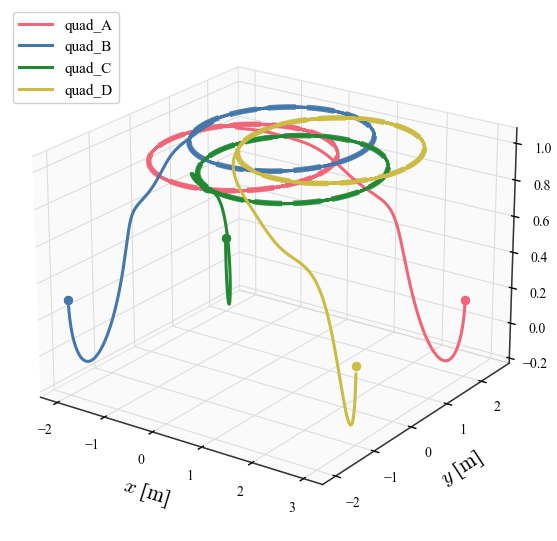

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


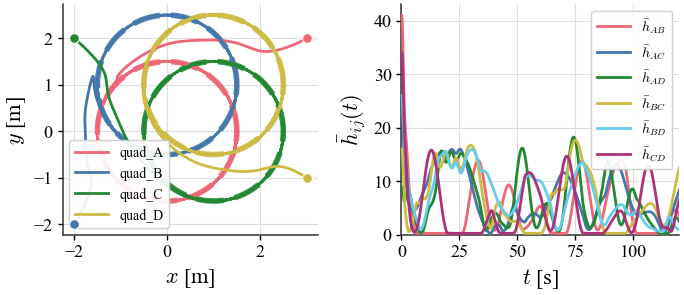

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


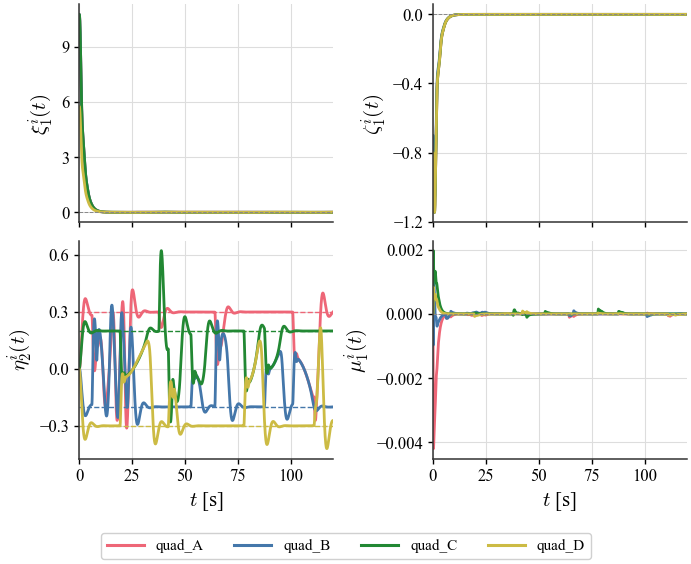

In [3]:
def main():
    env = make_env()
    agents = make_agents(env)

    sim = MultiQuadSim(agents)
    Tmax = 120
    dt = 0.02

    sim.run(Tmax=Tmax, dt=dt)
 
    plot_trajectories_3d(agents,        save_path="fig1_3d.eps")
    plot_xy_and_barrier(agents, D_s=Ds, save_path="fig2_xy_barrier.eps")
    plot_tracking_summary(agents,       save_path="fig3_summary.eps")


if __name__ == "__main__":
    main()